In [4]:
!pip install catboost


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import precision_recall_curve, f1_score as f1_fn
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score, f1_score, precision_recall_curve, average_precision_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import os
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings('ignore')

# ── Global plot style
plt.rcParams.update({
    'figure.facecolor':  '#0e1117',
    'axes.facecolor':    '#0e1117',
    'axes.edgecolor':    '#30363d',
    'axes.labelcolor':   '#c9d1d9',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.grid':         True,
    'grid.color':        '#21262d',
    'grid.linewidth':    0.5,
    'text.color':        '#c9d1d9',
    'xtick.color':       '#8b949e',
    'ytick.color':       '#8b949e',
    'font.family':       'sans-serif',
    'font.size':         11,
    'legend.facecolor':  '#161b22',
    'legend.edgecolor':  '#30363d',
    'legend.fontsize':   10,
    'figure.dpi':        120,
    'savefig.dpi':       150,
})

# Color palette
PAL = {
    'red':    '#f85149',
    'green':  '#3fb950',
    'blue':   '#58a6ff',
    'orange': '#d29922',
    'purple': '#bc8cff',
    'teal':   '#39d353',
    'cyan':   '#79c0ff',
    'pink':   '#f778ba',
    'gray':   '#8b949e',
}
GRAD_CMAP = sns.color_palette('rocket_r', as_cmap=True)

In [6]:
df_train_data_fixed = pd.read_csv(
    'train_data_fixed.csv',
    skiprows=lambda i: i > 0 and np.random.rand() > 0.1
)

In [7]:
df_train_data_fixed.head(10)

,psp_order_id,order_id,customer_account_id,shop_id,order_created_at,transaction_type,merchant_token_type,traffic_source,settle_interval,antifraud_decision,...,cardbrand,cardtype,bank,card_holder,card_country,card_pan_type,payment_source,error_code,card_exp_relative_scaled,is_success
0,12178250466955b903ab74b,0df52c16d351fc3d9b0b3aadca9ab39441767659f93680...,426f2b9989be3fa8db258bcb3c65b5827ad88c9a9927dc...,17376,2026-01-01 00:00:04,token,recurring,NaN,120.0,pass,...,VISA,CREDIT,TINKER FEDERAL CREDIT UNION,NaN,USA,pan,card,NaN,197.0,1
1,12178253026955b906ac2c5,7eff6edcd28c60819014d276817500bb6c0db63e2e632b...,d2c894c8ac1d22d03b8bbc638fafc790bcbfde8b01b9c7...,20750,2026-01-01 00:00:07,token,recurring,NaN,24.0,pass,...,VISA,CREDIT,JSC UNIVERSAL BANK,NaN,UKR,pan,card,NaN,683.5,1
2,12178256366955b90aacf3d,0e9d9084d588f6f7e203dea79fe7cb3f697df13750f582...,2b2c1ef5b7d20d480db4603fdda5fa803ee7b223333973...,20750,2026-01-01 00:00:10,token,recurring,NaN,24.0,pass,...,VISA,CREDIT,JSC UNIVERSAL BANK,NaN,UKR,pan,card,NaN,683.5,1
3,12178256376955b909acefd,e0fe1eb792aa883db6c11acc1cc1d63780b561c8b49744...,61b28b1e22ee34fe897bfa3dfb1d484c515cb2e885fe80...,17010,2026-01-01 00:00:10,token,recurring,NaN,24.0,pass,...,VISA,CREDIT,JSC UNIVERSAL BANK,NaN,UKR,pan,card,NaN,424.5,1
4,12178263096955b931b6952,3ef3ed7d230c25732375ab2ce9b9d6fa47cce153460f54...,506f3120fcee7c705bf5cf2a044534fe151084c423fd1f...,14340,2026-01-01 00:00:49,token,retry,NaN,120.0,pass,...,VISA,CREDIT,STRIDE BANK NA,NaN,USA,dpan,apple-pay,NaN,1094.5,1
5,12178264276955b93bb9102,37d107ef286c28a7fceb69db45f7aef6195a38e62a85f2...,54c13b1d06cb8158703dd56e5dbab8deb80be87875f5d9...,18762,2026-01-01 00:01:00,token,recurring,NaN,120.0,pass,...,VISA,DEBIT,HDFC BANK LTD,a5825c8a39b7ede9d30d4a483ab2e35ccce36a42a317fd...,IND,pan,card,0.03,1110.0,0
6,12178270976955b954bf043,51727a603c66e33eb43cd4944554545acfb7c3efb21215...,6327980747b2037c8090b73e82cc762b17c4e5540cfebe...,36841,2026-01-01 00:01:24,first,NaN,NaN,120.0,review,...,AMEX,CREDIT,AMERICAN EXPRESS US CONSUMER,NaN,USA,dpan,apple-pay,NaN,516.5,1
7,12178274886955b970c5e91,a304fa7d805ce57b18f01907fecd8e0f093b175cc4135d...,9f1de193ffbee010b66464978a9f698092127c91189bdb...,16806,2026-01-01 00:01:52,token,recurring,NaN,120.0,pass,...,MASTERCARD,CREDIT,ERSTE BANK DER OSTERREICHISCHEN SPARKASSEN AG,NaN,AUT,pan,card,3.10,562.5,0
8,12178275276955b975c742a,6c18cae490be1bcc17d37793ba8ce73b142cd9b2dcaa81...,9997f24bd3bbaa6696ca6d2ec7006c2bcb971f4bb7b72e...,17122,2026-01-01 00:01:58,first,NaN,8be9f71485488ff011bd250a3e18cbe2cd52ec4f3f4df0...,120.0,pass,...,MASTERCARD,DEBIT,UNITED COMMUNITY BANK,NaN,USA,pan,card,3.08,486.0,0
9,12178276236955b977c7c59,c6ce21ce47edff2bfb680f3950b217cf79db7f4eb42b60...,043c1a9898f03d553359526dab31776b66482fc8c3805b...,18762,2026-01-01 00:02:00,token,recurring,NaN,120.0,pass,...,VISA,DEBIT,NAVY FEDERAL CREDIT UNION,5794a788aeb0782c2367b4d7042aa57a46803c8b1b7ac3...,USA,pan,card,NaN,637.5,1


In [8]:
df_test = pd.read_csv('test.csv')

In [9]:
df_test.head(10)

,psp_order_id,order_id,customer_account_id,shop_id,order_created_at,transaction_type,merchant_token_type,traffic_source,settle_interval,antifraud_decision,...,descriptor,cardbrand,cardtype,bank,card_holder,card_country,card_pan_type,payment_source,error_code,card_exp_relative_scaled
0,1317034493699c1ac6898c5,d047e84edc6a47fa5b8841c94367d74087ce5f97f2b924...,NaN,15432,2026-02-23 09:15:51,token,recurring,NaN,NaN,pass,...,66f0af02da45d8b5492537ecd4d1329a858fb5fc7b64c8...,VISA,CREDIT,ACBA CREDIT AGRICOLE BANK CJSC,NaN,ARM,pan,card,3.02.2,78.5
1,1317034507699c1ac789bfa,30ad8ae08b751a077a90f77c2972f176070bcb47e8300a...,60540a39e092beb11064a6a5d92bd51f4282217fe2946b...,17444,2026-02-23 09:15:52,token,recurring,6cbb9fe41d87feaed9f20529c66022f5f852582d3c5ee7...,119.0,pass,...,4af91c82d3e0f9a0fa9772215b1685665931a779f75dd6...,VISA,PREPAID,ECOBANK SENEGAL,c5e976c30d1e5ef30cb7c8815a5987d34170a4b831d346...,SEN,pan,card,NaN,398.0
2,1317034508699c1ac889de6,e173e58102e3d0a23f19f9e3901294765d39673e514b06...,22beeb4cbd28e532cf5ef37654010aa8af5da9c67a3386...,22284,2026-02-23 09:15:52,token,1-click,NaN,144.0,pass,...,65c043c3671be9882b8b791215efc763fc8ec78ec01b21...,MASTERCARD,CREDIT,MASTERCAJAS SA,NaN,ESP,pan,card,3.08,793.5
3,1317034508699c1ac98a2cd,e173e58102e3d0a23f19f9e3901294765d39673e514b06...,22beeb4cbd28e532cf5ef37654010aa8af5da9c67a3386...,22284,2026-02-23 09:15:53,token,1-click,NaN,144.0,pass,...,65c043c3671be9882b8b791215efc763fc8ec78ec01b21...,MASTERCARD,CREDIT,MASTERCAJAS SA,NaN,ESP,pan,card,3.08,793.5
4,1317034542699c1aca8a5b6,9f78325f64b078c740fad3f53f87f2d14391abaceb5bb0...,00594b56d177eefd3419300bb100eebe9a7567eeb094cf...,17226,2026-02-23 09:15:54,first,NaN,aa6b31ab1d500d7227a740abf8d6f8fb79f5dac7bbafba...,120.0,pass,...,87fee7ce8bb934b9666b118236c46012b95131455df98d...,MASTERCARD,DEBIT,CAPITEC BANK LTD,NaN,ZAF,dpan,google-pay,NaN,536.0
5,1317034558699c1acc8aec8,a0ae49ce6f4f16373c8e6d12cd1efe689436827dd97fc6...,32e315a039d436295e155e51d3c0a83dd3cd1f218d2dd4...,14942,2026-02-23 09:15:56,first,NaN,NaN,144.0,force_3d,...,66c5c175fa16da6c09af58e734f27fee7e7913c6e6d8b3...,VISA,DEBIT,BANCA TRANSILVANIA SA,NaN,ROU,dpan,apple-pay,NaN,1022.0
6,1317034562699c1acd8b0e0,603b9a991cf7a881a08b719a2862b769526ddf308479e7...,bcc5cd8658ccabf14ebeaaa354c158a06a8d9ea52e297a...,14340,2026-02-23 09:15:57,token,retry,NaN,120.0,pass,...,1bb17959e67f5d5e952099afb1e25c04088e707803d6ee...,VISA,DEBIT,THE BANCORP BANK NA,NaN,USA,dpan,apple-pay,3.02,1022.0
7,1317034593699c1acf8b9e1,3f5109788e329361b5b15df57fc9c218bf39a2a0c9b09e...,1450d4a3fb54b9599aed8a9514a31e93a54606befdd6b9...,17444,2026-02-23 09:15:59,first,NaN,6cbb9fe41d87feaed9f20529c66022f5f852582d3c5ee7...,119.0,pass,...,4af91c82d3e0f9a0fa9772215b1685665931a779f75dd6...,MASTERCARD,DEBIT,JSC UNIVERSAL BANK,NaN,UKR,dpan,apple-pay,NaN,505.0
8,1317034656699c1ad28c596,886118eda507e0ec4b6c9b96f2e8b8bb9b05a3ddf72253...,1885433213fc2a2e2150cf47fe81a0558ec9408f770d93...,37245,2026-02-23 09:16:02,first,NaN,NaN,NaN,pass,...,8960f06cca523692752c1593e3c1d75c944b32c9f6bfbd...,MASTERCARD,DEBIT,BELFIUS BANK NV BELFIUS BANQUE SA,7cc9052af9982f8ec6fff1e8b7d048503f26701e222563...,BEL,pan,card,5.01,839.5
9,1317034845699c1ad38cbf8,d5ef42c74347f0752c9b45302a27ae1f6d8f0373367905...,8a4f39ecb5ea275a1a35f139db80c2c7713869520bc805...,22284,2026-02-23 09:16:04,token,recurring,NaN,144.0,pass,...,65c043c3671be9882b8b791215efc763fc8ec78ec01b21...,MASTERCARD,DEBIT,REVOLUT LTD,NaN,DEU,pan,card,3.08,505.0


In [10]:
df_train_data_fixed.shape

(600664, 42)

In [11]:
df_train_data_fixed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600664 entries, 0 to 600663
Data columns (total 42 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   psp_order_id              600664 non-null  object 
 1   order_id                  600664 non-null  object 
 2   customer_account_id       566215 non-null  object 
 3   shop_id                   600664 non-null  int64  
 4   order_created_at          600664 non-null  object 
 5   transaction_type          600664 non-null  object 
 6   merchant_token_type       412459 non-null  object 
 7   traffic_source            135631 non-null  object 
 8   settle_interval           497258 non-null  float64
 9   antifraud_decision        600658 non-null  object 
 10  is_subscription           600664 non-null  bool   
 11  platform                  600664 non-null  object 
 12  cascade_number            587336 non-null  float64
 13  is_secured                600664 non-null  b

In [12]:
df_train_data_fixed.describe()

,shop_id,settle_interval,cascade_number,amount,amount_scaled,psp_id,acquiring_bank_id,mcc_id,card_exp_relative_scaled,is_success
count,600664.000000,497258.000000,587336.000000,6.006640e+05,600664.000000,600664.000000,598377.000000,595253.000000,600664.000000,600664.000000
mean,18358.755228,85.886946,1.159789,6.573120e+04,7.435719,1681.087010,1572.905723,612.432102,633.205436,0.431835
std,4298.991431,57.125022,0.440460,9.889953e+05,1.366551,1030.140533,1414.601625,69.358678,332.597388,0.495332
min,9.000000,0.000000,1.000000,0.000000e+00,0.000000,119.000000,1.000000,3.000000,-709.000000,0.000000
25%,15192.000000,0.000000,1.000000,1.459000e+03,6.907755,152.000000,776.000000,600.000000,407.000000,0.000000
50%,17226.000000,120.000000,1.000000,3.099000e+03,7.749753,1760.000000,1797.000000,613.000000,604.500000,0.000000
75%,20839.000000,120.000000,1.000000,4.999000e+03,8.294050,2780.000000,1798.000000,658.000000,860.500000,1.000000
max,37245.000000,240.000000,5.000000,1.596591e+08,13.500801,12798.000000,15790.000000,725.000000,10436.500000,1.000000


In [13]:
# # Show all unique values and their counts in all columns
# for col in df_train_data_fixed.columns:
#     unique_vals = df_train_data_fixed[col].unique()
#     print(f"--- Column: {col} ---")
#     print(f"Total Unique Values: {len(unique_vals)}")
#     if len(unique_vals) <= 20:
#         print(f"Values: {unique_vals}")
#     else:
#         print(f"Values (showing first 20): {unique_vals[:20]}")
#     print("-" * 50)


# EDA — Exploratory Data Analysis

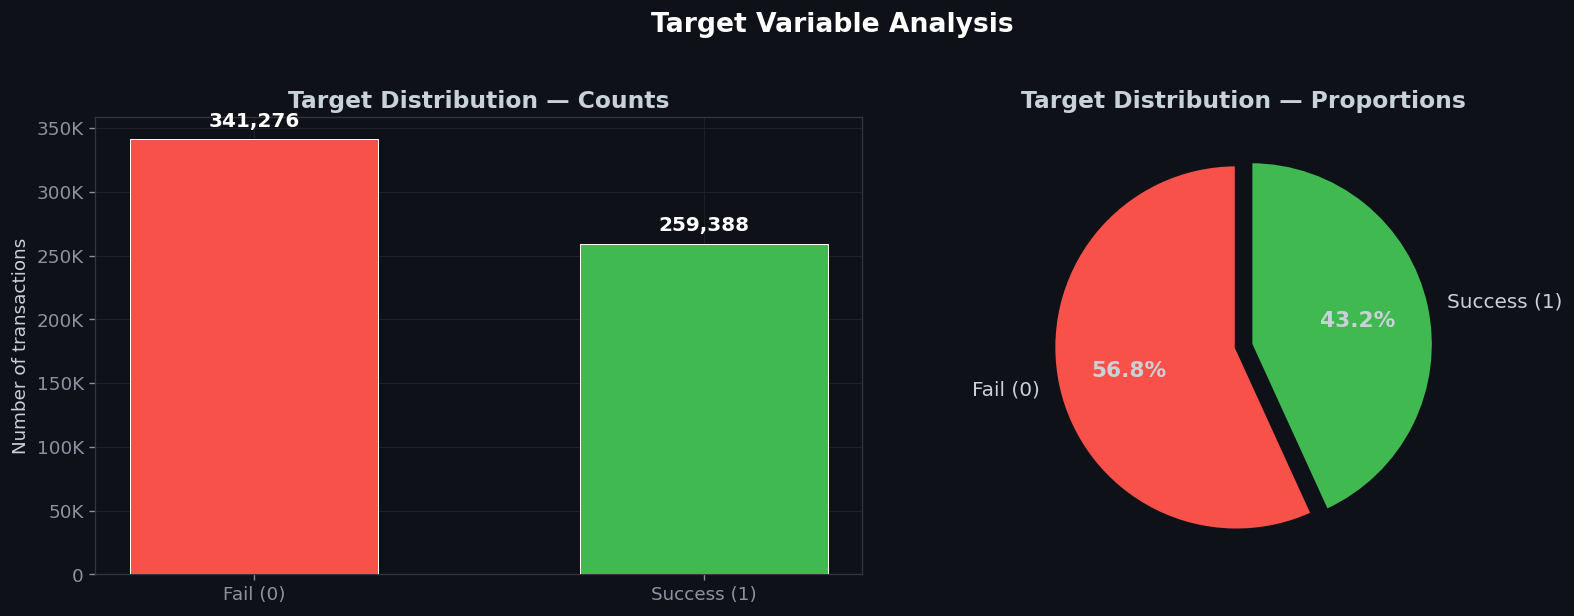

  Success rate: 43.18%  |  Fail rate: 56.82%  |  Total: 600,664


In [14]:
# --- 1. Target distribution ---
target_counts = df_train_data_fixed['is_success'].value_counts().sort_index()
target_pct = df_train_data_fixed['is_success'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [PAL['red'], PAL['green']]
bars0 = axes[0].bar(['Fail (0)', 'Success (1)'], target_counts.values, color=colors,
                     edgecolor='white', linewidth=0.6, width=0.55, zorder=3)
for bar, v in zip(bars0, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + target_counts.max() * 0.02,
                 f'{v:,.0f}', ha='center', va='bottom', fontweight='bold', fontsize=12, color='white')
axes[0].set_title('Target Distribution — Counts')
axes[0].set_ylabel('Number of transactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

wedges, texts, autotexts = axes[1].pie(
    target_pct.values, labels=['Fail (0)', 'Success (1)'], autopct='%1.1f%%',
    colors=colors, startangle=90, explode=(0.04, 0.04),
    textprops={'color': '#c9d1d9', 'fontsize': 12},
    wedgeprops={'edgecolor': '#0e1117', 'linewidth': 2})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(13)
axes[1].set_title('Target Distribution — Proportions')

fig.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()
print(f"  Success rate: {target_pct[1]:.2f}%  |  Fail rate: {target_pct[0]:.2f}%  |  Total: {len(df_train_data_fixed):,}")

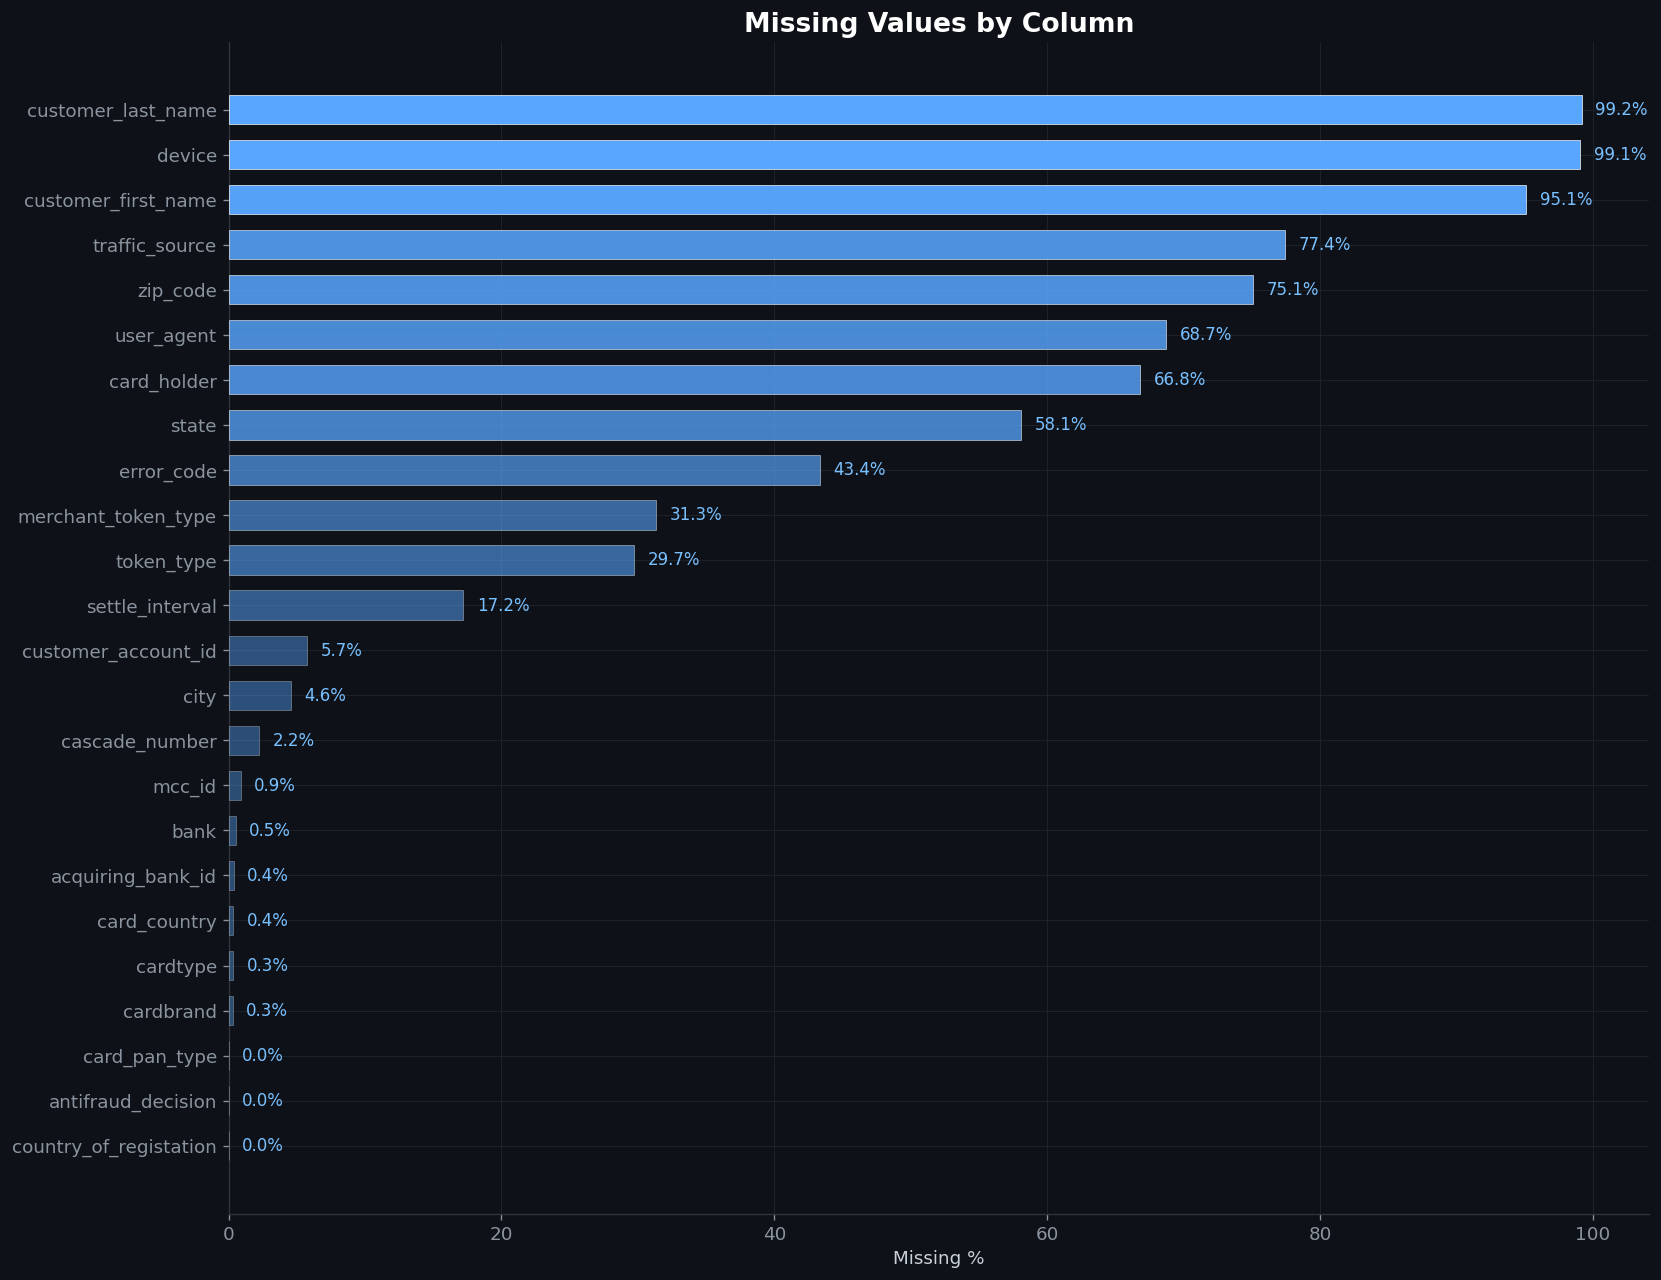


Columns with missing values: 24 / 42
                         count        pct
customer_last_name      595728  99.178243
device                  594961  99.050551
customer_first_name     571244  95.102087
traffic_source          465033  77.419822
zip_code                451045  75.091066
user_agent              412628  68.695311
card_holder             401199  66.792583
state                   349001  58.102533
error_code              260399  43.351857
merchant_token_type     188205  31.332825
token_type              178503  29.717613
settle_interval         103406  17.215282
customer_account_id      34449   5.735153
city                     27441   4.568444
cascade_number           13328   2.218878
mcc_id                    5411   0.900836
bank                      3084   0.513432
acquiring_bank_id         2287   0.380745
card_country              2177   0.362432
cardtype                  1918   0.319313
cardbrand                 1787   0.297504
card_pan_type               20   0.003

In [15]:
# --- 2. Missing values analysis ---
missing = df_train_data_fixed.isnull().sum()
missing_pct = (missing / len(df_train_data_fixed)) * 100
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct}).query('count > 0').sort_values('pct', ascending=True)

fig, ax = plt.subplots(figsize=(14, max(4, len(missing_df) * 0.45)))
bars = ax.barh(missing_df.index, missing_df['pct'], color=PAL['blue'],
               edgecolor='white', linewidth=0.4, height=0.65, zorder=3)

max_pct = missing_df['pct'].max()
for bar, pct in zip(bars, missing_df['pct']):
    alpha = 0.4 + 0.6 * (pct / max_pct) if max_pct > 0 else 0.8
    bar.set_alpha(alpha)

for bar, pct in zip(bars, missing_df['pct']):
    ax.text(bar.get_width() + max_pct * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=10, color=PAL['cyan'])

ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontsize=16, fontweight='bold', color='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print(f"\nColumns with missing values: {len(missing_df)} / {len(df_train_data_fixed.columns)}")
print(missing_df[['count','pct']].sort_values('pct', ascending=False).to_string())

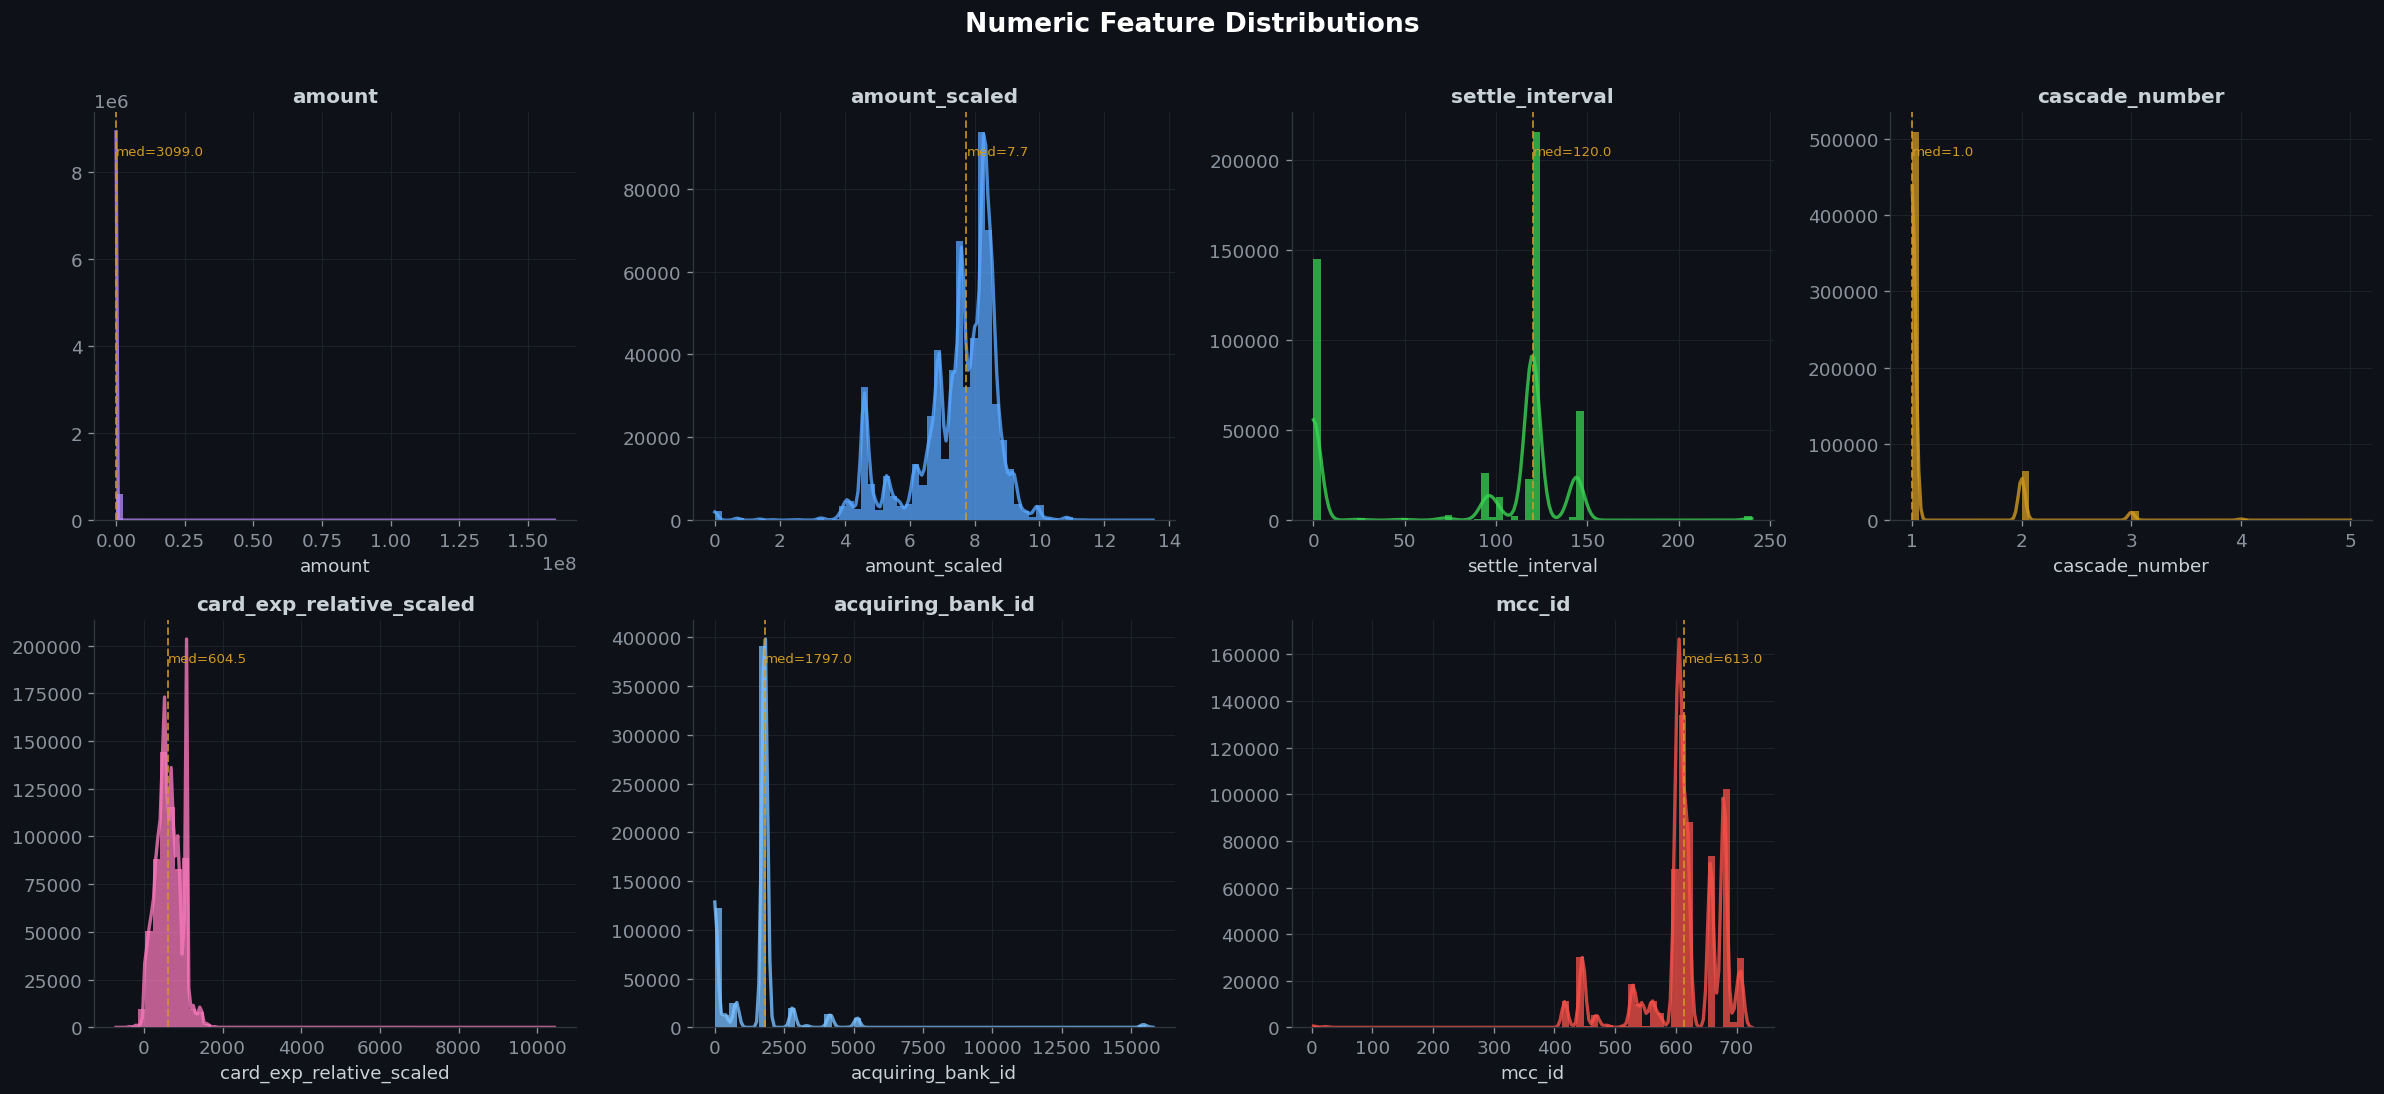

In [16]:
# --- 3. Numeric feature distributions ---
numeric_cols = ['amount', 'amount_scaled', 'settle_interval', 'cascade_number',
                'card_exp_relative_scaled', 'acquiring_bank_id', 'mcc_id']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.ravel()
palette = [PAL['purple'], PAL['blue'], PAL['teal'], PAL['orange'],
           PAL['pink'], PAL['cyan'], PAL['red']]

for i, col in enumerate(numeric_cols):
    data = df_train_data_fixed[col].dropna()
    sns.histplot(data, bins=60, ax=axes[i], color=palette[i], alpha=0.75,
                 kde=True, edgecolor='none', linewidth=0, zorder=3,
                 line_kws={'linewidth': 2, 'color': 'white', 'alpha': 0.8})
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('')
    med = data.median()
    axes[i].axvline(med, color=PAL['orange'], ls='--', lw=1.2, alpha=0.8, zorder=4)
    axes[i].text(med, axes[i].get_ylim()[1] * 0.92, f'med={med:.1f}',
                 fontsize=8, color=PAL['orange'], ha='left', va='top')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Numeric Feature Distributions', fontsize=16, fontweight='bold', color='white', y=1.01)
plt.tight_layout()
plt.show()

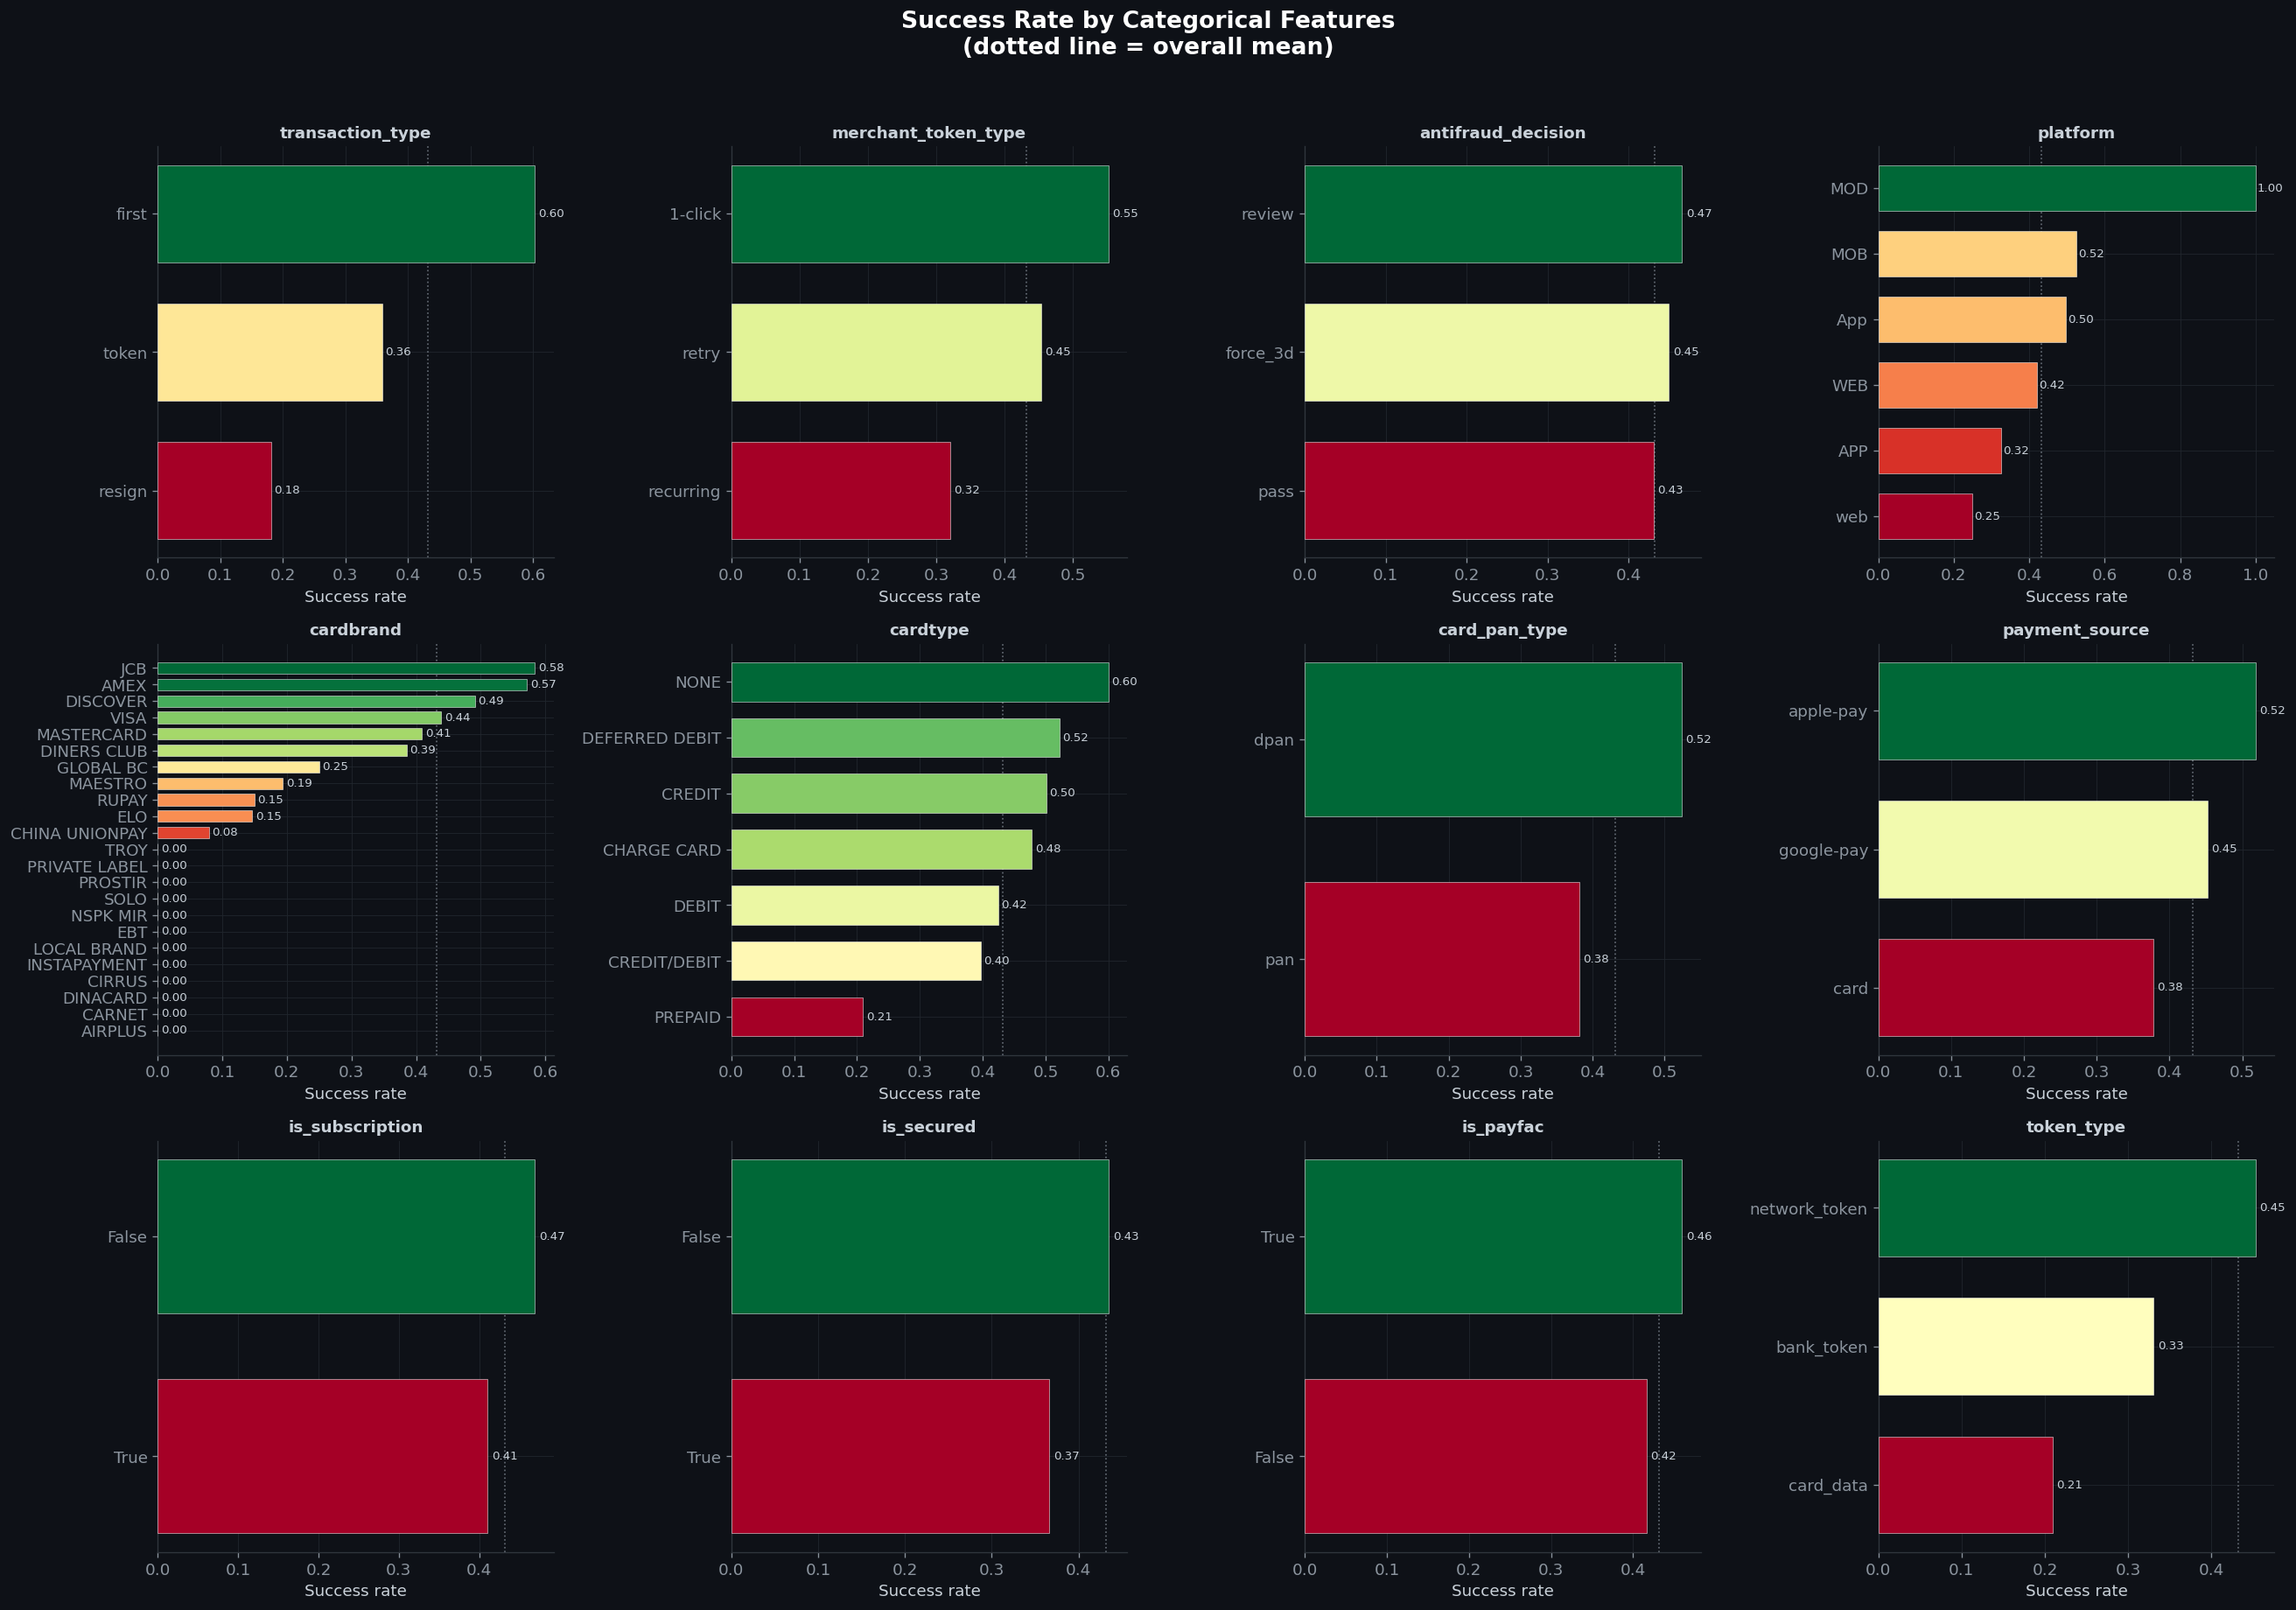

In [17]:
# --- 4. Success rate by key categorical features ---
cat_cols_for_analysis = ['transaction_type', 'merchant_token_type', 'antifraud_decision',
                          'platform', 'cardbrand', 'cardtype', 'card_pan_type',
                          'payment_source', 'is_subscription', 'is_secured', 'is_payfac', 'token_type']

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
axes = axes.ravel()

for i, col in enumerate(cat_cols_for_analysis):
    sr = df_train_data_fixed.groupby(col)['is_success'].agg(['mean', 'count'])
    sr = sr.sort_values('mean', ascending=True)

    norm = plt.Normalize(sr['mean'].min(), sr['mean'].max())
    bar_colors = [plt.cm.RdYlGn(norm(v)) for v in sr['mean']]

    bars = axes[i].barh(sr.index.astype(str), sr['mean'], color=bar_colors,
                        edgecolor='white', linewidth=0.3, height=0.7, zorder=3)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Success rate')
    axes[i].axvline(df_train_data_fixed['is_success'].mean(), color=PAL['gray'],
                    ls=':', lw=1, alpha=0.7, zorder=2)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

    for bar, val in zip(bars, sr['mean']):
        axes[i].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                     f'{val:.2f}', va='center', fontsize=8, color='#c9d1d9')

for j in range(len(cat_cols_for_analysis), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Success Rate by Categorical Features\n(dotted line = overall mean)',
             fontsize=16, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

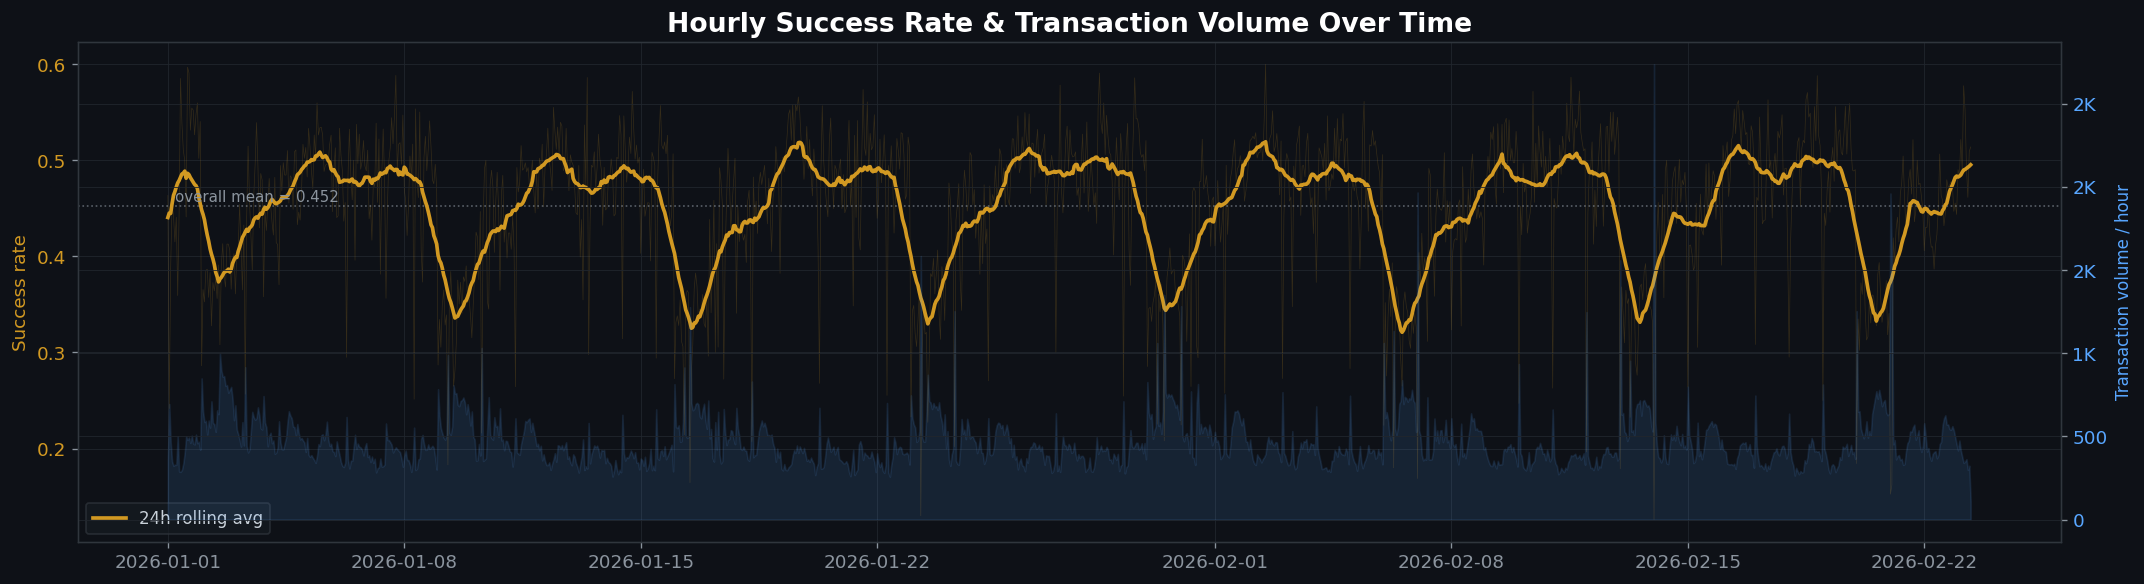

In [18]:
# --- 5. Success rate over time (hourly) ---
df_train_data_fixed['order_created_at'] = pd.to_datetime(df_train_data_fixed['order_created_at'])
hourly = df_train_data_fixed.set_index('order_created_at')['is_success'].resample('1h')
hourly_sr = hourly.mean()
hourly_vol = hourly.count()

fig, ax1 = plt.subplots(figsize=(18, 5))

ax2 = ax1.twinx()
ax2.fill_between(hourly_vol.index, hourly_vol.values, alpha=0.12, color=PAL['blue'], zorder=1)
ax2.set_ylabel('Transaction volume / hour', color=PAL['blue'], fontsize=10)
ax2.tick_params(axis='y', labelcolor=PAL['blue'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

rolling_sr = hourly_sr.rolling(24, center=True, min_periods=6).mean()
ax1.plot(hourly_sr.index, hourly_sr.values, color=PAL['orange'], alpha=0.2, linewidth=0.4, zorder=2)
ax1.plot(rolling_sr.index, rolling_sr.values, color=PAL['orange'], linewidth=2.2, zorder=3, label='24h rolling avg')
ax1.axhline(hourly_sr.mean(), color=PAL['gray'], ls=':', lw=1, alpha=0.6)
ax1.text(hourly_sr.index[5], hourly_sr.mean() + 0.005,
         f'overall mean = {hourly_sr.mean():.3f}', fontsize=9, color=PAL['gray'])

ax1.set_ylabel('Success rate', color=PAL['orange'])
ax1.set_title('Hourly Success Rate & Transaction Volume Over Time',
              fontsize=16, fontweight='bold', color='white')
ax1.legend(loc='lower left', framealpha=0.7)
ax1.tick_params(axis='y', labelcolor=PAL['orange'])
plt.tight_layout()
plt.show()

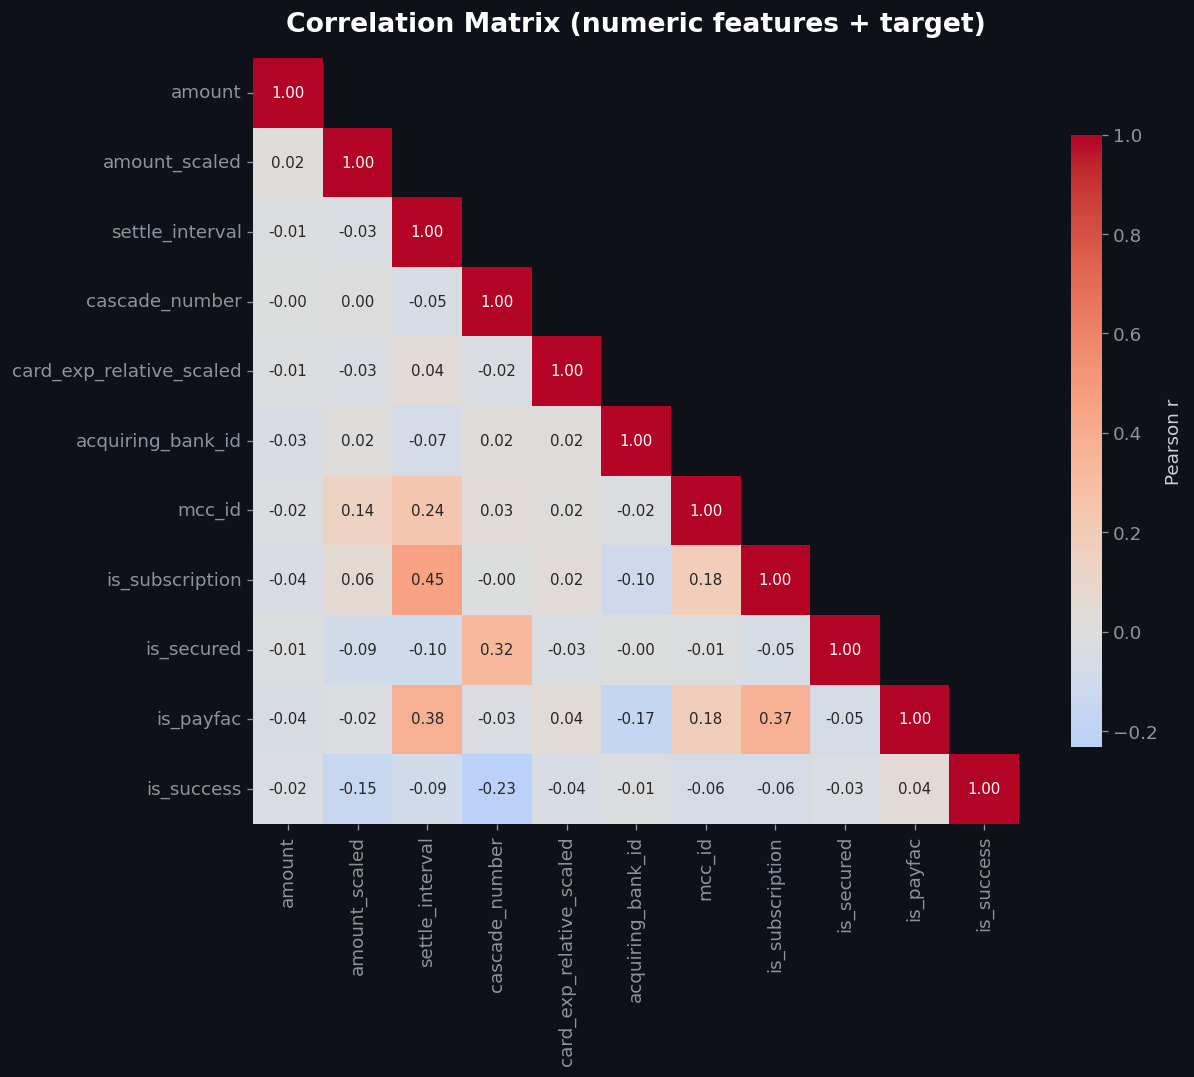

In [19]:
# --- 6. Correlation heatmap (numeric cols) ---
num_df = df_train_data_fixed[['amount', 'amount_scaled', 'settle_interval', 'cascade_number',
                               'card_exp_relative_scaled', 'acquiring_bank_id', 'mcc_id',
                               'is_subscription', 'is_secured', 'is_payfac', 'is_success']].copy()
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, square=True, linewidths=0,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
            annot_kws={'fontsize': 9})

ax.set_title('Correlation Matrix (numeric features + target)',
             fontsize=16, fontweight='bold', color='white', pad=16)

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

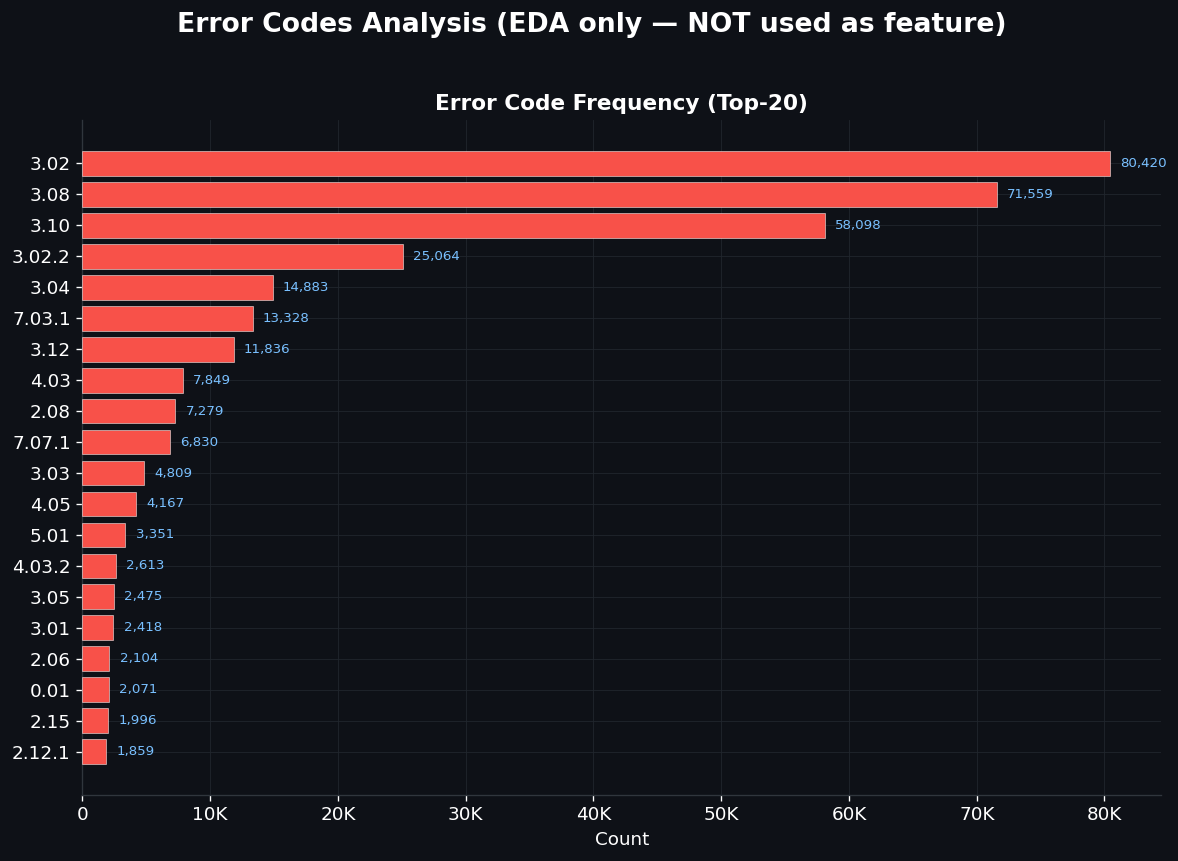

In [20]:
# --- 7. Top-20 error codes by frequency and their success rate ---
# NOTE: error_code is DATA LEAKAGE in raw form — this EDA cell is for analysis only.
error_stats = df_train_data_fixed.groupby('error_code')['is_success'].agg(['mean', 'count']).sort_values('count', ascending=False).head(20)
error_stats = error_stats.sort_values('count', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars_l = ax.barh(error_stats.index.astype(str), error_stats['count'],
                       color=PAL['red'], edgecolor='white', linewidth=0.3, zorder=3)
ax.set_title('Error Code Frequency (Top-20)', fontsize=13, fontweight='bold', color='white')
ax.set_xlabel('Count', color='white')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'))

for bar, v in zip(bars_l, error_stats['count']):
    ax.text(bar.get_width() + error_stats['count'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2, f'{v:,.0f}',
                 va='center', fontsize=8, color=PAL['cyan'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(colors='white')

fig.suptitle('Error Codes Analysis (EDA only — NOT used as feature)',
             fontsize=16, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

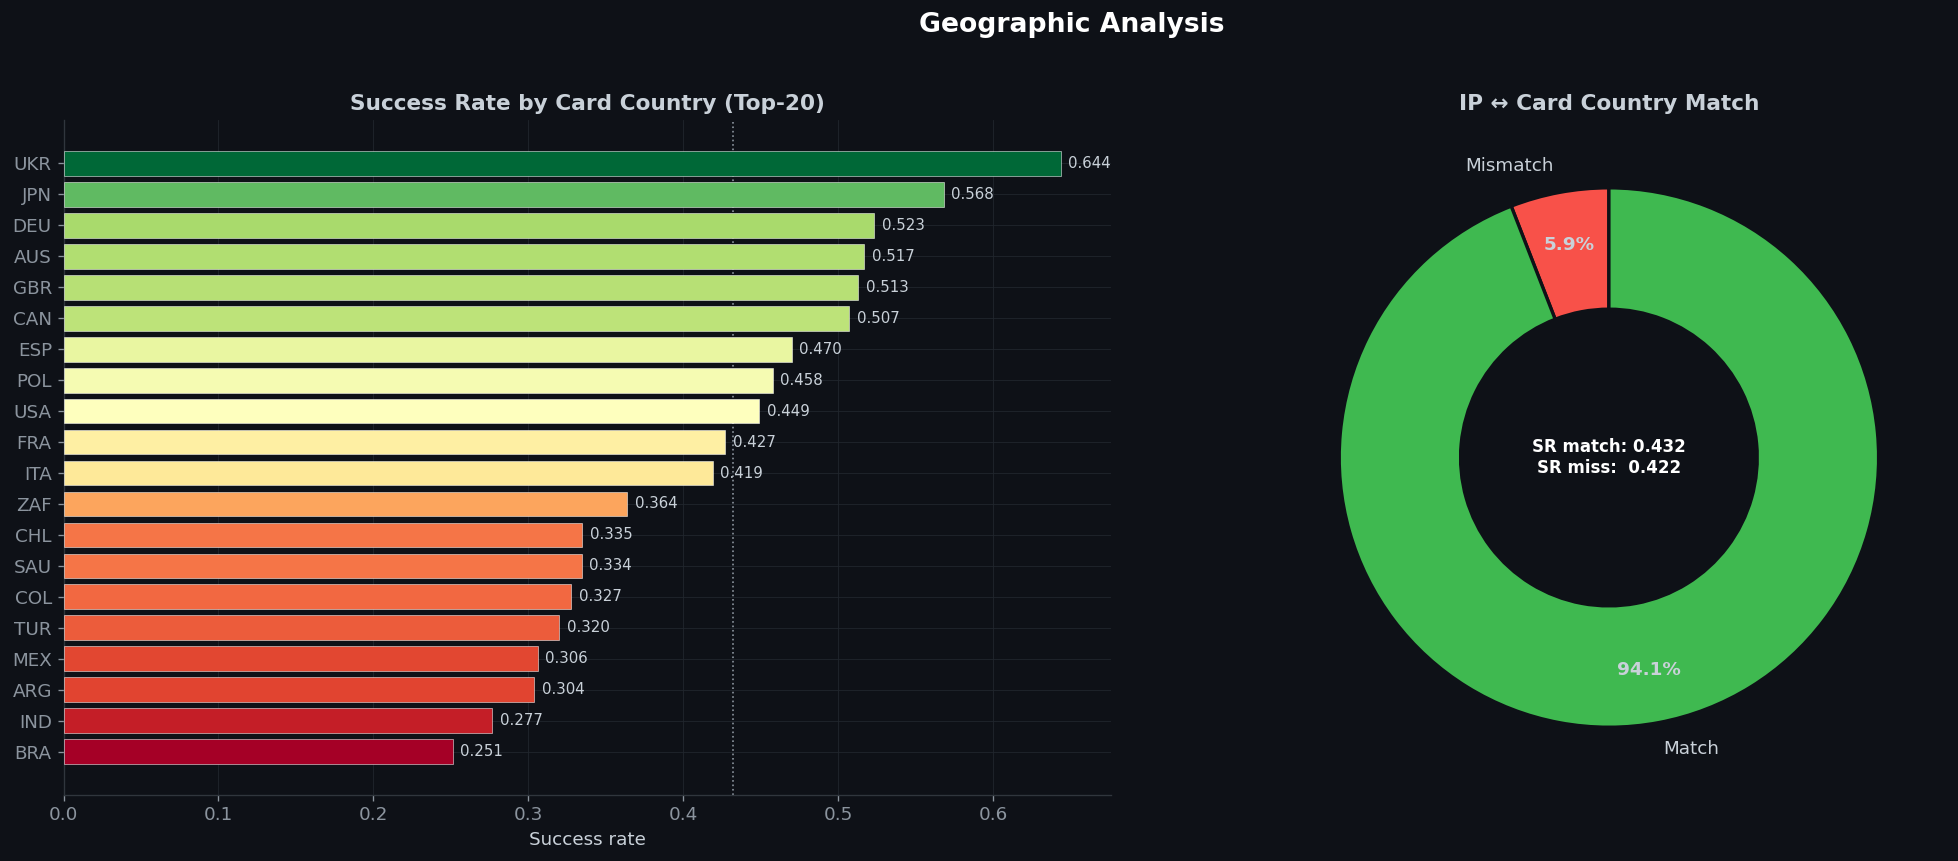

In [21]:
# --- 8. Success rate by card_country (top-20) & ip_country vs card_country match ---
top_countries = df_train_data_fixed['card_country'].value_counts().head(20).index
country_data = df_train_data_fixed[df_train_data_fixed['card_country'].isin(top_countries)].groupby('card_country')['is_success'].agg(['mean', 'count'])
country_data = country_data.sort_values('mean', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

norm = plt.Normalize(country_data['mean'].min(), country_data['mean'].max())
c_colors = [plt.cm.RdYlGn(norm(v)) for v in country_data['mean']]
bars = axes[0].barh(country_data.index.astype(str), country_data['mean'],
                    color=c_colors, edgecolor='white', linewidth=0.3, zorder=3)
axes[0].axvline(df_train_data_fixed['is_success'].mean(), color=PAL['gray'], ls=':', lw=1)
axes[0].set_title('Success Rate by Card Country (Top-20)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Success rate')
for bar, v in zip(bars, country_data['mean']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                 f'{v:.3f}', va='center', fontsize=9, color='#c9d1d9')

match_col = df_train_data_fixed['ip_country'] == df_train_data_fixed['card_country']
match_sr = df_train_data_fixed.groupby(match_col)['is_success'].agg(['mean', 'count'])
match_labels = ['Mismatch', 'Match']
match_colors = [PAL['red'], PAL['green']]
wedges, texts, autotexts = axes[1].pie(
    match_sr['count'], labels=match_labels, autopct='%1.1f%%',
    colors=match_colors, startangle=90, pctdistance=0.8,
    textprops={'color': '#c9d1d9', 'fontsize': 11},
    wedgeprops={'edgecolor': '#0e1117', 'linewidth': 2, 'width': 0.45})
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('IP ↔ Card Country Match', fontsize=13, fontweight='bold')

sr_match = match_sr.loc[True, 'mean'] if True in match_sr.index else 0
sr_mismatch = match_sr.loc[False, 'mean'] if False in match_sr.index else 0
axes[1].text(0, 0, f'SR match: {sr_match:.3f}\nSR miss:  {sr_mismatch:.3f}',
             ha='center', va='center', fontsize=10, color='white', fontweight='bold')

for ax in [axes[0]]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Geographic Analysis', fontsize=16, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

# Feature Engineering

In [22]:
# --- Combine train + test for consistent feature engineering ---
df_test['order_created_at'] = pd.to_datetime(df_test['order_created_at'])
df_train_data_fixed['is_train'] = 1
df_test['is_train'] = 0
df_all = pd.concat([df_train_data_fixed, df_test], axis=0, ignore_index=True)
print(f"Combined shape: {df_all.shape}  |  Train: {df_train_data_fixed.shape[0]}  |  Test: {df_test.shape[0]}")

Combined shape: (1267981, 43)  |  Train: 600664  |  Test: 667317


In [23]:
# --- 1. Datetime features ---
df_all['hour'] = df_all['order_created_at'].dt.hour
df_all['dayofweek'] = df_all['order_created_at'].dt.dayofweek
df_all['day'] = df_all['order_created_at'].dt.day
df_all['month'] = df_all['order_created_at'].dt.month
df_all['is_weekend'] = (df_all['dayofweek'] >= 5).astype(int)
df_all['is_night'] = ((df_all['hour'] >= 22) | (df_all['hour'] <= 5)).astype(int)

print("Datetime features created: hour, dayofweek, day, month, is_weekend, is_night")

Datetime features created: hour, dayofweek, day, month, is_weekend, is_night


In [24]:
# --- 2. Country-matching & missing-indicator features ---
df_all['country_match'] = (df_all['ip_country'] == df_all['card_country']).astype(int)
df_all['card_holder_missing'] = df_all['card_holder'].isnull().astype(int)
df_all['traffic_source_missing'] = df_all['traffic_source'].isnull().astype(int)
df_all['customer_name_missing'] = (df_all['customer_first_name'].isnull() & df_all['customer_last_name'].isnull()).astype(int)

# NOTE: error_code_missing removed — raw error_code is data leakage
print("Indicator features created: country_match, card_holder_missing, traffic_source_missing, customer_name_missing")

Indicator features created: country_match, card_holder_missing, traffic_source_missing, customer_name_missing


In [25]:
# --- 3. Platform normalisation ---
df_all['platform'] = df_all['platform'].str.upper()

print("Platform values after normalisation:", df_all['platform'].value_counts().to_dict())

Platform values after normalisation: {'WEB': 1010660, 'MOB': 194931, 'APP': 62387, 'MOD': 3}


In [26]:
# --- 4. Frequency-encoding for high-cardinality hashed columns ---
# These columns are hashed (SHA-like), so we use frequency encoding
high_card_cols = ['order_id', 'customer_account_id', 'traffic_source', 'currency',
                  'descriptor', 'bank', 'card_country', 'ip_country']

for col in high_card_cols:
    freq = df_all[col].value_counts()
    df_all[f'{col}_freq'] = df_all[col].map(freq)

print(f"Frequency-encoded {len(high_card_cols)} columns: {', '.join(c + '_freq' for c in high_card_cols)}")

Frequency-encoded 8 columns: order_id_freq, customer_account_id_freq, traffic_source_freq, currency_freq, descriptor_freq, bank_freq, card_country_freq, ip_country_freq


In [27]:
# --- 5. Aggregation features: shop-level statistics ---
# Use only TRAIN data to avoid target leakage
train_mask = df_all['is_train'] == 1

shop_stats = df_all.loc[train_mask].groupby('shop_id').agg(
    shop_txn_count=('is_success', 'count'),
    shop_success_rate=('is_success', 'mean'),
    shop_avg_amount=('amount', 'mean'),
    shop_std_amount=('amount', 'std'),
    shop_unique_customers=('customer_account_id', 'nunique'),
).reset_index()
shop_stats['shop_std_amount'] = shop_stats['shop_std_amount'].fillna(0)

df_all = df_all.merge(shop_stats, on='shop_id', how='left')
print(f"Shop-level features added: {list(shop_stats.columns[1:])}")

Shop-level features added: ['shop_txn_count', 'shop_success_rate', 'shop_avg_amount', 'shop_std_amount', 'shop_unique_customers']


In [28]:
# --- 6. Aggregation features: psp-level statistics ---
psp_stats = df_all.loc[train_mask].groupby('psp_id').agg(
    psp_txn_count=('is_success', 'count'),
    psp_success_rate=('is_success', 'mean'),
    psp_avg_amount=('amount', 'mean'),
).reset_index()

df_all = df_all.merge(psp_stats, on='psp_id', how='left')
print(f"PSP-level features added: {list(psp_stats.columns[1:])}")

PSP-level features added: ['psp_txn_count', 'psp_success_rate', 'psp_avg_amount']


In [29]:
# --- 7. Aggregation features: card_country-level statistics ---
country_stats = df_all.loc[train_mask].groupby('card_country').agg(
    card_country_txn_count=('is_success', 'count'),
    card_country_success_rate=('is_success', 'mean'),
).reset_index()

df_all = df_all.merge(country_stats, on='card_country', how='left')
print(f"Card-country-level features added: {list(country_stats.columns[1:])}")

Card-country-level features added: ['card_country_txn_count', 'card_country_success_rate']


In [30]:
# --- 8. Interaction features ---
df_all['amount_vs_shop_avg'] = df_all['amount'] / (df_all['shop_avg_amount'] + 1)

# Cascade > 1 means retry
df_all['is_retry'] = (df_all['cascade_number'] > 1).astype(int)

# Card expiry bucket (binned)
df_all['card_exp_bucket'] = pd.cut(df_all['card_exp_relative_scaled'],
                                    bins=[-np.inf, 100, 300, 600, 1000, np.inf],
                                    labels=[0, 1, 2, 3, 4]).astype(float)

# Amount bucket (log-scale already present via amount_scaled)
df_all['amount_bucket'] = pd.cut(df_all['amount_scaled'],
                                  bins=[-np.inf, 4, 6, 8, 10, np.inf],
                                  labels=[0, 1, 2, 3, 4]).astype(float)

print("Interaction features created: amount_vs_shop_avg, is_retry, card_exp_bucket, amount_bucket")

Interaction features created: amount_vs_shop_avg, is_retry, card_exp_bucket, amount_bucket


In [31]:
# --- 8b. Derived error_code feature (CASCADE LOGIC — NOT leakage) ---
# For each order_id with cascade_number > 1, get the error_code from the PREVIOUS
# cascade attempt. This is valid because in real life the payment system knows
# why the previous attempt failed before launching the next one.

df_all = df_all.sort_values(['order_id', 'cascade_number']).reset_index(drop=True)

df_all['prev_error_code'] = df_all.groupby('order_id')['error_code'].shift(1)

df_all['has_prev_error'] = df_all['prev_error_code'].notna().astype(int)

df_all['prev_cascade_count'] = df_all.groupby('order_id').cumcount()

print(f"Derived cascade features created: prev_error_code, has_prev_error, prev_cascade_count")
print(f"prev_error_code fill rate: {df_all['prev_error_code'].notna().mean():.3%}")
print(f"prev_error_code top values:\n{df_all['prev_error_code'].value_counts().head(10)}")

Derived cascade features created: prev_error_code, has_prev_error, prev_cascade_count
prev_error_code fill rate: 0.976%
prev_error_code top values:
prev_error_code
3.10      4441
3.08      3246
3.04      1125
7.07.1     866
3.03       340
4.03       279
4.05       223
2.15       220
6.03       204
3.01       140
Name: count, dtype: int64


In [32]:
# --- 9. Drop columns that are not useful for modelling ---
# Save order_created_at for time-based train/val split before dropping
_train_order_dates = df_all.loc[df_all['is_train'] == 1, 'order_created_at'].values
# Save test psp_order_id in sorted order (df_all was sorted by order_id+cascade)
_test_psp_order_ids = df_all.loc[df_all['is_train'] == 0, 'psp_order_id'].values

drop_cols = [
    'psp_order_id',        # unique ID
    'order_id',            # hashed, used for freq-encoding already
    'customer_account_id', # hashed, used for freq-encoding already
    'traffic_source',      # hashed, used for freq-encoding already
    'order_created_at',    # extracted datetime features
    'customer_first_name', # hashed PII
    'customer_last_name',  # hashed PII
    'card_holder',         # hashed PII
    'zip_code',            # hashed, too many unique
    'state',               # hashed
    'city',                # hashed
    'device',              # too many unique, mostly NaN
    'user_agent',          # too many unique
    'error_code',          # DATA LEAKAGE — raw error_code is forbidden
]

df_all = df_all.drop(columns=drop_cols, errors='ignore')
print(f"Dropped {len(drop_cols)} columns (including raw error_code). Remaining: {df_all.shape[1]} columns")

Dropped 14 columns (including raw error_code). Remaining: 64 columns


In [33]:
# --- 10. Define categorical features for CatBoost ---
cat_features = ['transaction_type', 'merchant_token_type', 'antifraud_decision',
                'platform', 'token_type', 'currency', 'ip_country', 'descriptor',
                'cardbrand', 'cardtype', 'bank', 'card_country', 'card_pan_type',
                'payment_source', 'country_of_registation',
                'prev_error_code']
for col in cat_features:
    if col in df_all.columns:
        df_all[col] = df_all[col].fillna('missing').astype(str)

print(f"Categorical features ({len(cat_features)}): {cat_features}")

Categorical features (16): ['transaction_type', 'merchant_token_type', 'antifraud_decision', 'platform', 'token_type', 'currency', 'ip_country', 'descriptor', 'cardbrand', 'cardtype', 'bank', 'card_country', 'card_pan_type', 'payment_source', 'country_of_registation', 'prev_error_code']


In [34]:
# --- 11. Split back into train / test ---
df_train_fe = df_all[df_all['is_train'] == 1].copy().drop(columns=['is_train'])
df_test_fe  = df_all[df_all['is_train'] == 0].copy().drop(columns=['is_train', 'is_success'])

exclude = ['is_success']
feature_cols = [c for c in df_train_fe.columns if c not in exclude]

X_train = df_train_fe[feature_cols]
y_train = df_train_fe['is_success']
X_test  = df_test_fe[feature_cols]

cat_feature_indices = [i for i, c in enumerate(feature_cols) if c in cat_features]

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Target distribution:\n{y_train.value_counts()}")
print(f"\nCategorical feature indices ({len(cat_feature_indices)}): {cat_feature_indices}")
print(f"Feature columns ({len(feature_cols)}):")
for i, c in enumerate(feature_cols):
    tag = ' [cat]' if c in cat_features else ''
    print(f"  {i:3d}. {c}{tag}")

X_train: (600664, 62)  |  X_test: (667317, 62)
Target distribution:
is_success
0.0    341276
1.0    259388
Name: count, dtype: int64

Categorical feature indices (16): [1, 2, 4, 6, 9, 11, 13, 16, 19, 20, 21, 22, 23, 24, 25, 59]
Feature columns (62):
    0. shop_id
    1. transaction_type [cat]
    2. merchant_token_type [cat]
    3. settle_interval
    4. antifraud_decision [cat]
    5. is_subscription
    6. platform [cat]
    7. cascade_number
    8. is_secured
    9. token_type [cat]
   10. amount
   11. currency [cat]
   12. amount_scaled
   13. ip_country [cat]
   14. psp_id
   15. acquiring_bank_id
   16. country_of_registation [cat]
   17. mcc_id
   18. is_payfac
   19. descriptor [cat]
   20. cardbrand [cat]
   21. cardtype [cat]
   22. bank [cat]
   23. card_country [cat]
   24. card_pan_type [cat]
   25. payment_source [cat]
   26. card_exp_relative_scaled
   27. hour
   28. dayofweek
   29. day
   30. month
   31. is_weekend
   32. is_night
   33. country_match
   34. card_h

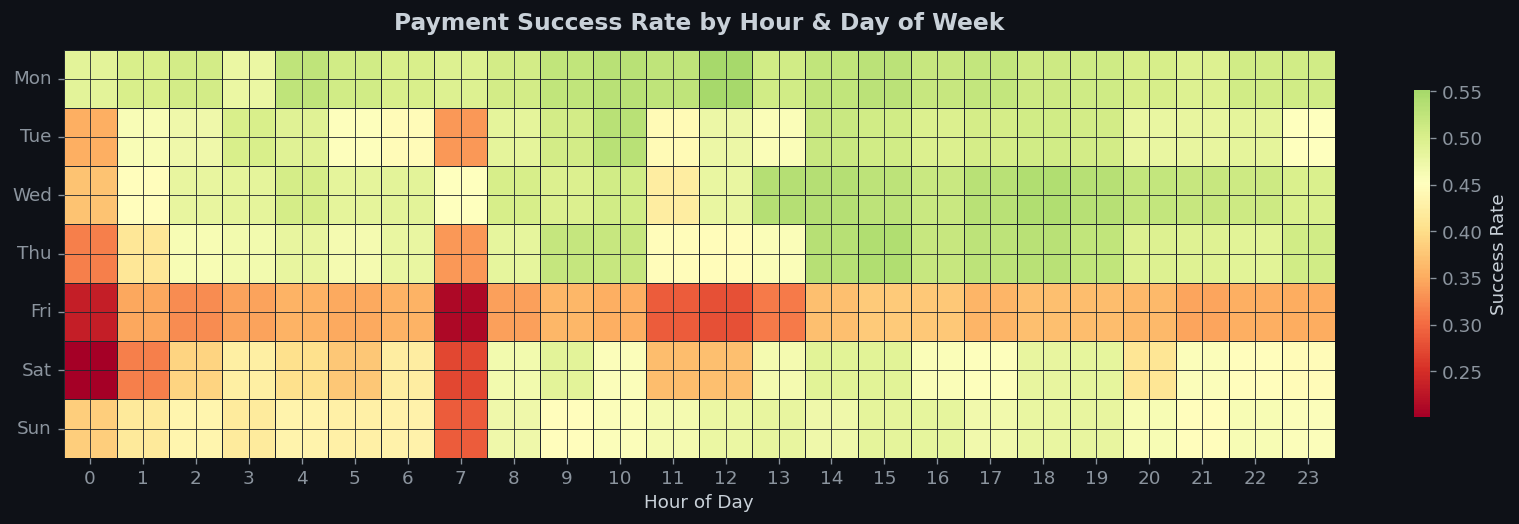

→ Insight: visible temporal patterns justify hour, dayofweek, is_weekend, is_night features


In [35]:
# Success Rate Heatmap — Hour × Day of Week
# Business hypothesis: payment success depends on time of day and day of week
# (bank processing windows, fraud patterns, user behaviour)

pivot = df_train_fe.groupby(['dayofweek', 'hour'])['is_success'].mean().unstack()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(14, 4.5))
sns.heatmap(pivot, cmap='RdYlGn', center=pivot.values.mean(),
            linewidths=0.3, linecolor='#21262d',
            xticklabels=True, yticklabels=day_labels,
            cbar_kws={'label': 'Success Rate', 'shrink': 0.8},
            ax=ax, annot=False, fmt='.2f')
ax.set_title('Payment Success Rate by Hour & Day of Week', pad=12)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

print("→ Insight: visible temporal patterns justify hour, dayofweek, is_weekend, is_night features")

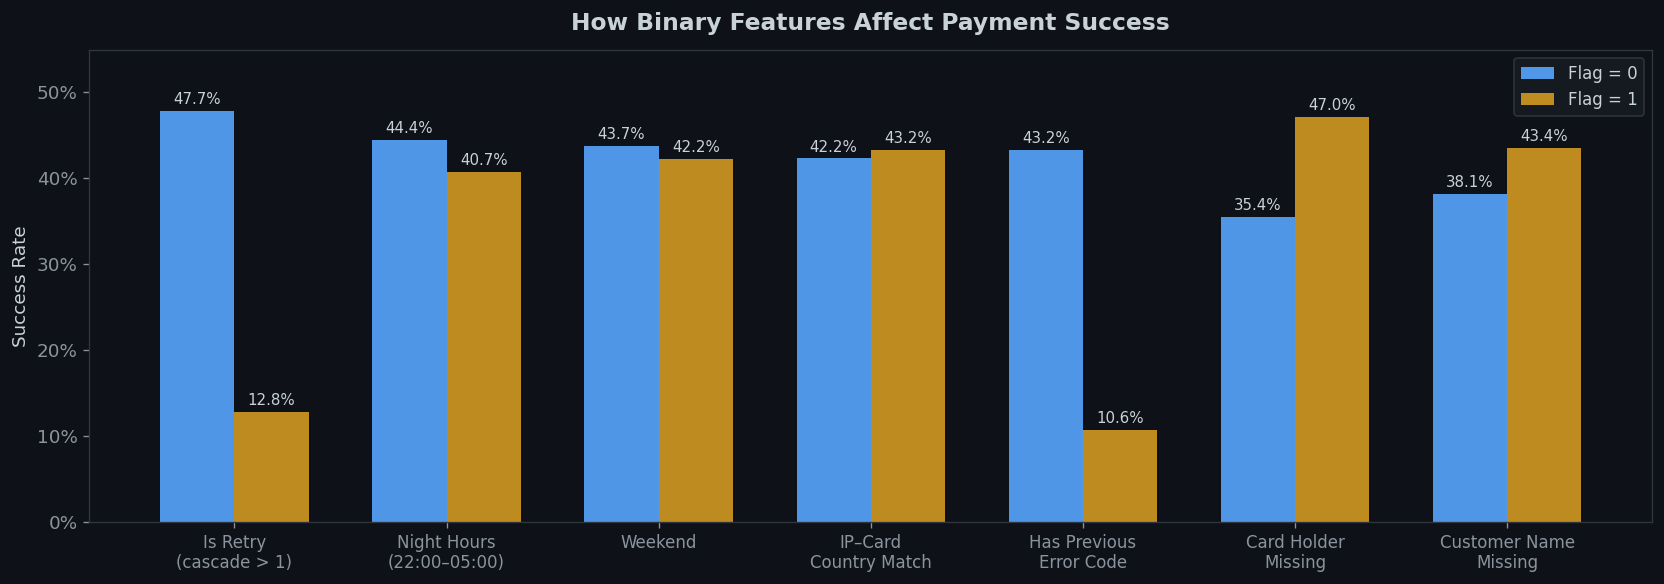

→ Insight: retries, night hours, and country mismatch noticeably reduce success rate


In [36]:
# Binary / Indicator Features — Impact on Success Rate ─────
# Business hypotheses: retries signal previous failure, night/weekend have
# different bank availability, country mismatch raises fraud risk

binary_feats = {
    'is_retry':              'Is Retry\n(cascade > 1)',
    'is_night':              'Night Hours\n(22:00–05:00)',
    'is_weekend':            'Weekend',
    'country_match':         'IP–Card\nCountry Match',
    'has_prev_error':        'Has Previous\nError Code',
    'card_holder_missing':   'Card Holder\nMissing',
    'customer_name_missing': 'Customer Name\nMissing',
}

rates = {}
for col, label in binary_feats.items():
    grp = df_train_fe.groupby(col)['is_success'].mean()
    rates[label] = {0: grp.get(0, 0), 1: grp.get(1, 0)}

labels = list(rates.keys())
rate_0 = [rates[l][0] for l in labels]
rate_1 = [rates[l][1] for l in labels]

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars0 = ax.bar(x - w/2, rate_0, w, label='Flag = 0', color=PAL['blue'], edgecolor='none', alpha=0.9)
bars1 = ax.bar(x + w/2, rate_1, w, label='Flag = 1', color=PAL['orange'], edgecolor='none', alpha=0.9)

for bar_group in [bars0, bars1]:
    for bar in bar_group:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f'{h:.1%}',
                ha='center', va='bottom', fontsize=9, color='#c9d1d9')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Success Rate')
ax.set_title('How Binary Features Affect Payment Success', pad=12)
ax.set_ylim(0, max(max(rate_0), max(rate_1)) * 1.15)
ax.grid(False)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

print("→ Insight: retries, night hours, and country mismatch noticeably reduce success rate")

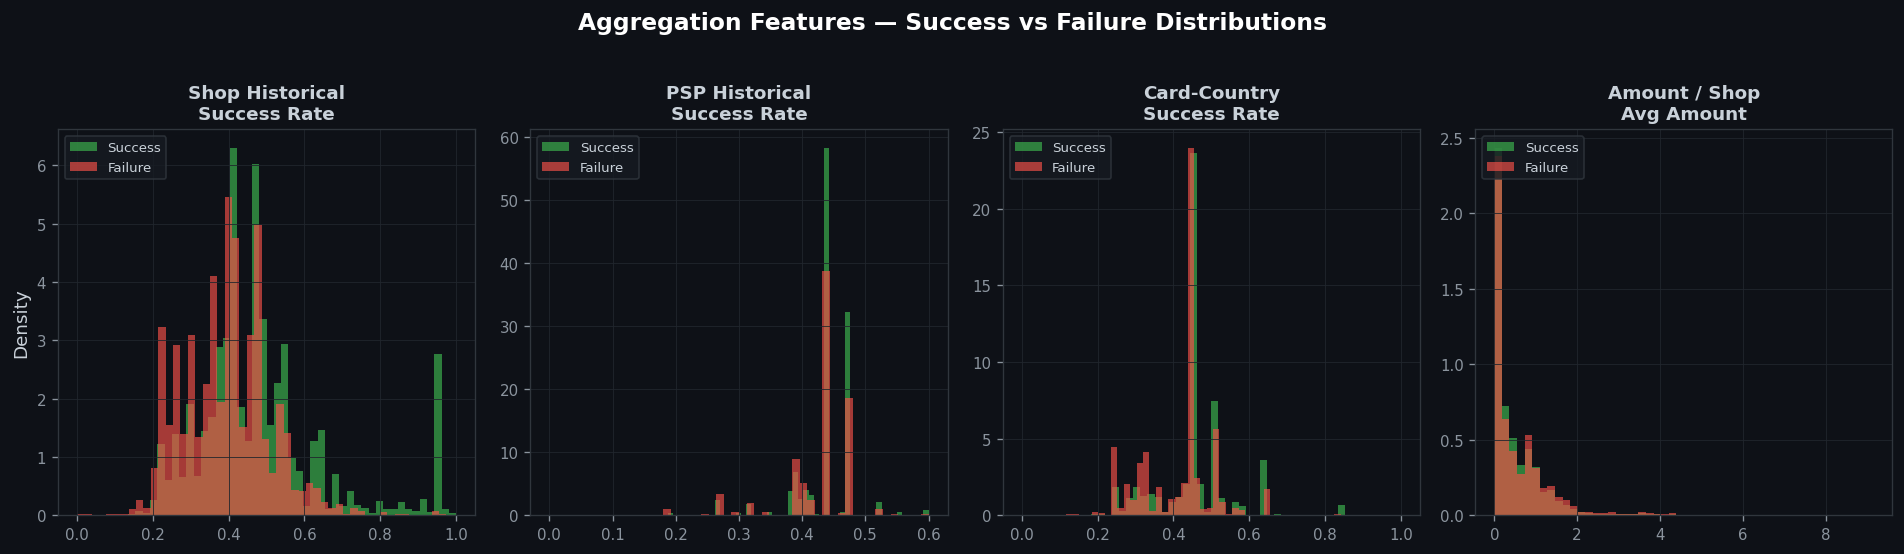

→ Insight: success concentrates at higher shop/PSP/country success rates — strong predictive signal


In [37]:
# Aggregation Features — Distribution by Outcome ───────────
# Business hypothesis: shops/PSPs with historically low success rates
# produce more failures; amount deviating from shop average is risky

agg_feats = {
    'shop_success_rate':       'Shop Historical\nSuccess Rate',
    'psp_success_rate':        'PSP Historical\nSuccess Rate',
    'card_country_success_rate': 'Card-Country\nSuccess Rate',
    'amount_vs_shop_avg':      'Amount / Shop\nAvg Amount',
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for ax, (col, title) in zip(axes, agg_feats.items()):
    data_ok   = df_train_fe.loc[df_train_fe['is_success'] == 1, col].dropna()
    data_fail = df_train_fe.loc[df_train_fe['is_success'] == 0, col].dropna()

    if col == 'amount_vs_shop_avg':
        q99 = df_train_fe[col].quantile(0.99)
        data_ok   = data_ok[data_ok <= q99]
        data_fail = data_fail[data_fail <= q99]

    ax.hist(data_ok,   bins=50, density=True, alpha=0.65, color=PAL['green'], label='Success')
    ax.hist(data_fail, bins=50, density=True, alpha=0.65, color=PAL['red'],   label='Failure')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_ylabel('Density' if ax == axes[0] else '')
    ax.tick_params(labelsize=9)

fig.suptitle('Aggregation Features — Success vs Failure Distributions',
             fontsize=14, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.show()

print("→ Insight: success concentrates at higher shop/PSP/country success rates — strong predictive signal")

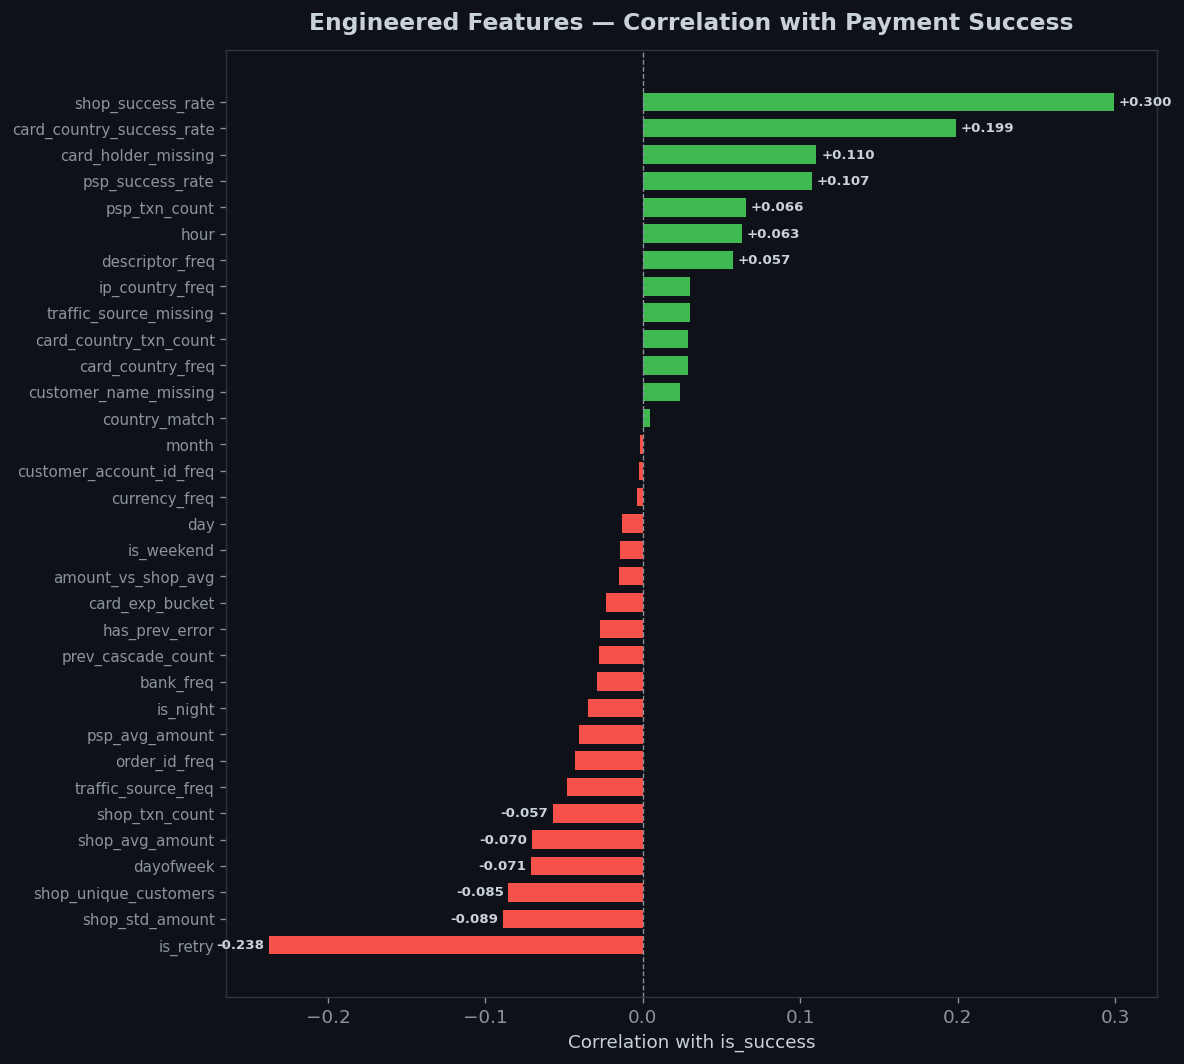

→ Insight: shop/psp/card-country success rates and cascade features show strongest correlations


In [38]:
# Correlation of All Engineered Features with Target ────────
# Summary view: which new features have the strongest linear association
# with is_success (point-biserial correlation)

new_features = [
    # Datetime
    'hour', 'dayofweek', 'day', 'month', 'is_weekend', 'is_night',
    # Indicators
    'country_match', 'card_holder_missing', 'traffic_source_missing', 'customer_name_missing',
    # Frequency encodings
    'order_id_freq', 'customer_account_id_freq', 'traffic_source_freq',
    'currency_freq', 'descriptor_freq', 'bank_freq', 'card_country_freq', 'ip_country_freq',
    # Aggregations
    'shop_txn_count', 'shop_success_rate', 'shop_avg_amount', 'shop_std_amount', 'shop_unique_customers',
    'psp_txn_count', 'psp_success_rate', 'psp_avg_amount',
    'card_country_txn_count', 'card_country_success_rate',
    # Interaction
    'amount_vs_shop_avg', 'is_retry', 'card_exp_bucket',
    # Cascade-derived
    'has_prev_error', 'prev_cascade_count',
]

existing = [f for f in new_features if f in df_train_fe.columns]
corrs = df_train_fe[existing + ['is_success']].corr()['is_success'].drop('is_success')
corrs = corrs.sort_values()

colors = [PAL['red'] if v < 0 else PAL['green'] for v in corrs.values]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(range(len(corrs)), corrs.values, color=colors, edgecolor='none', height=0.7)
ax.set_yticks(range(len(corrs)))
ax.set_yticklabels(corrs.index, fontsize=9)
ax.set_xlabel('Correlation with is_success')
ax.set_title('Engineered Features — Correlation with Payment Success', pad=12)
ax.axvline(0, color=PAL['gray'], lw=0.8, ls='--')
ax.grid(False)

for i, (feat, val) in enumerate(corrs.items()):
    if abs(val) > 0.05:
        ax.text(val + (0.003 if val > 0 else -0.003), i,
                f'{val:+.3f}', va='center', ha='left' if val > 0 else 'right',
                fontsize=8, color='#c9d1d9', fontweight='bold')

plt.tight_layout()
plt.show()

print("→ Insight: shop/psp/card-country success rates and cascade features show strongest correlations")

# Model Training & Evaluation

In [39]:
# --- Time-based train/validation split ---
train_dates = pd.Series(_train_order_dates)
cutoff = train_dates.quantile(0.8)
print(f"Time-based split cutoff: {cutoff}")

val_mask = (train_dates >= cutoff).values
X_tr, X_val = X_train[~val_mask], X_train[val_mask]
y_tr, y_val = y_train[~val_mask], y_train[val_mask]

print(f"Train: {X_tr.shape}  |  Val: {X_val.shape}")
print(f"Train success rate: {y_tr.mean():.4f}  |  Val success rate: {y_val.mean():.4f}")

Time-based split cutoff: 2026-02-13 02:00:30
Train: (480531, 62)  |  Val: (120133, 62)
Train success rate: 0.4350  |  Val success rate: 0.4190


In [40]:
train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_indices)
val_pool = Pool(X_val, y_val, cat_features=cat_feature_indices)

model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=3,
    eval_metric='AUC',
    loss_function='Logloss',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=200,
    auto_class_weights='Balanced',
    task_type='GPU',
)

model.fit(train_pool, eval_set=val_pool, use_best_model=True)
print(f"\nBest iteration: {model.best_iteration_}")

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7995161	best: 0.7995161 (0)	total: 519ms	remaining: 8m 38s
200:	test: 0.8621821	best: 0.8621821 (200)	total: 1m	remaining: 4m 2s
400:	test: 0.8697221	best: 0.8697221 (400)	total: 2m 1s	remaining: 3m 2s
600:	test: 0.8728751	best: 0.8728751 (600)	total: 3m 3s	remaining: 2m 1s
800:	test: 0.8746995	best: 0.8746995 (800)	total: 4m 4s	remaining: 1m
999:	test: 0.8758146	best: 0.8758146 (999)	total: 5m 6s	remaining: 0us
bestTest = 0.8758145869
bestIteration = 999

Best iteration: 999


ROC-AUC:          0.87581
Average Precision: 0.83098
Precision:         0.72818
Recall:            0.80369
F1:                0.76407


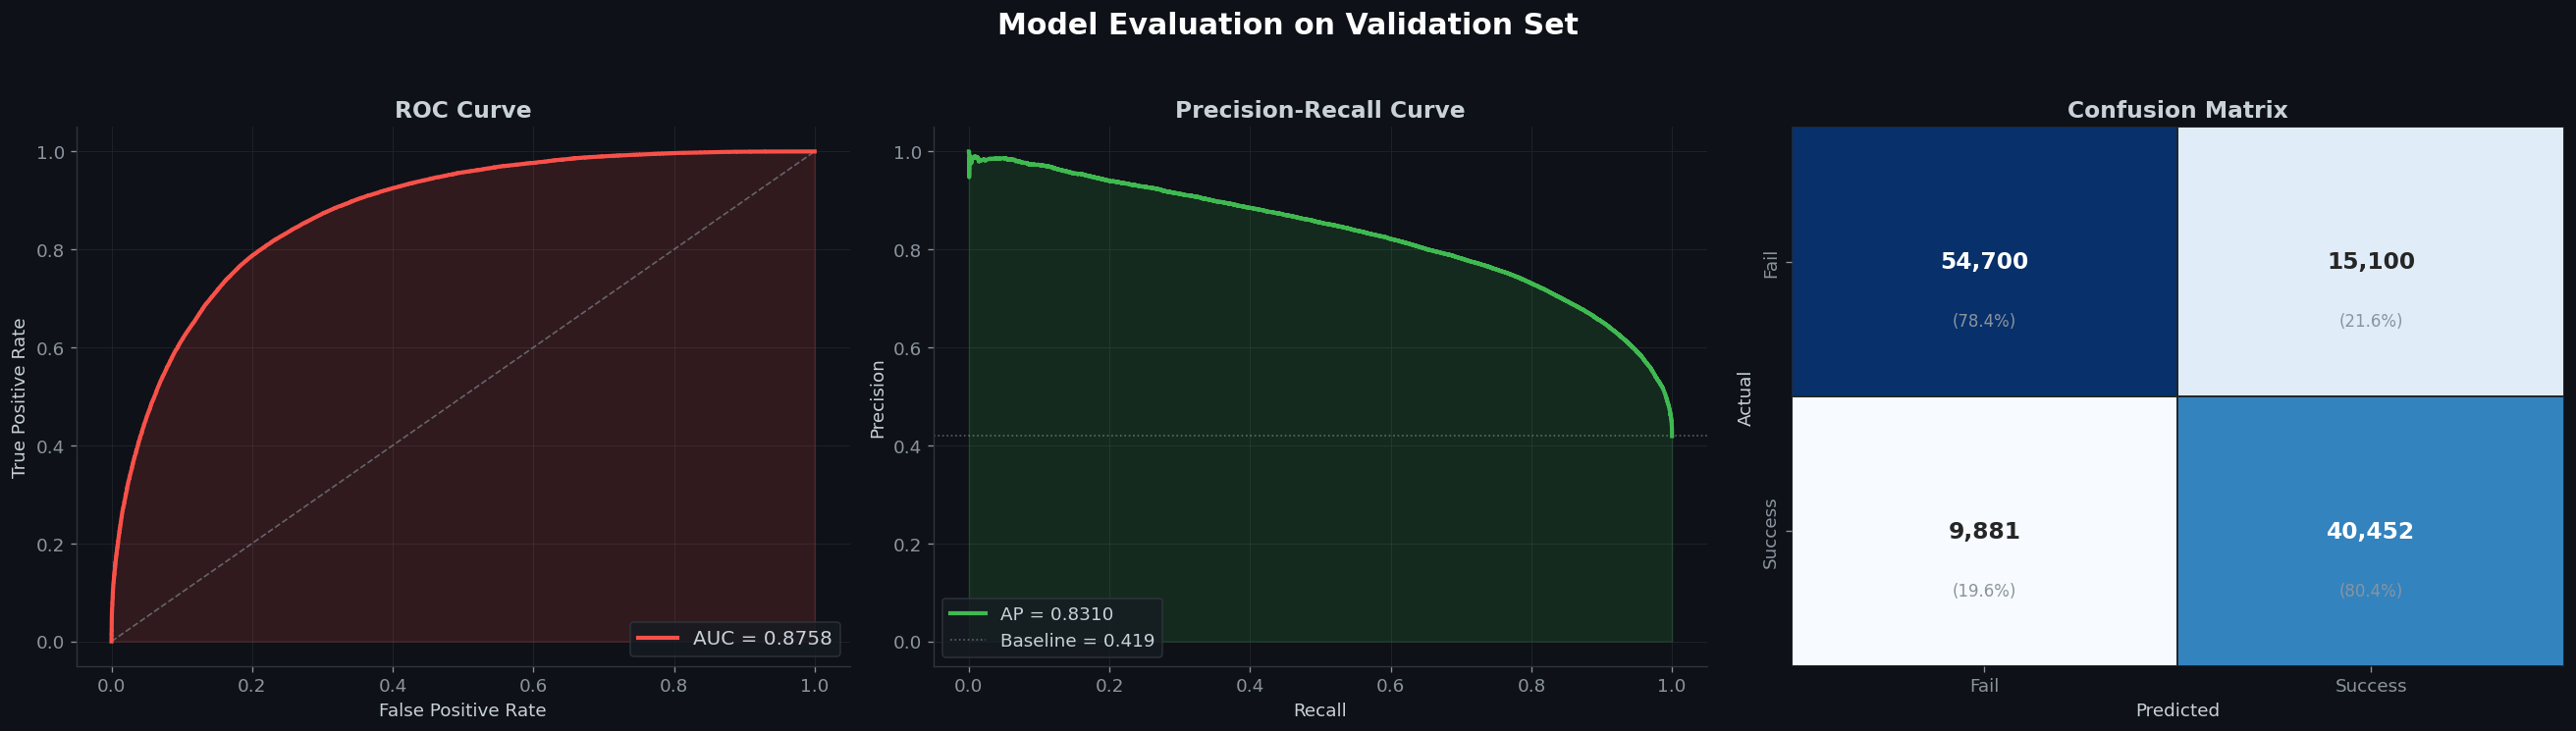


Classification report:
              precision    recall  f1-score   support

        Fail       0.85      0.78      0.81     69800
     Success       0.73      0.80      0.76     50333

    accuracy                           0.79    120133
   macro avg       0.79      0.79      0.79    120133
weighted avg       0.80      0.79      0.79    120133



In [41]:
# --- Evaluation metrics on validation set ---

y_val_proba = model.predict_proba(val_pool)[:, 1]
y_val_pred  = model.predict(val_pool)

roc_auc = roc_auc_score(y_val, y_val_proba)
ap = average_precision_score(y_val, y_val_proba)
prec_s = precision_score(y_val, y_val_pred)
rec_s = recall_score(y_val, y_val_pred)
f1_s = f1_score(y_val, y_val_pred)

print(f"ROC-AUC:          {roc_auc:.5f}")
print(f"Average Precision: {ap:.5f}")
print(f"Precision:         {prec_s:.5f}")
print(f"Recall:            {rec_s:.5f}")
print(f"F1:                {f1_s:.5f}")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

fpr, tpr, _ = roc_curve(y_val, y_val_proba)
axes[0].fill_between(fpr, tpr, alpha=0.15, color=PAL['red'], zorder=2)
axes[0].plot(fpr, tpr, color=PAL['red'], lw=2.5, zorder=3, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], '--', color=PAL['gray'], lw=1, alpha=0.6)
axes[0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=12, loc='lower right')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

prec_arr, rec_arr, _ = precision_recall_curve(y_val, y_val_proba)
axes[1].fill_between(rec_arr, prec_arr, alpha=0.15, color=PAL['green'], step='post', zorder=2)
axes[1].step(rec_arr, prec_arr, color=PAL['green'], lw=2.5, where='post', zorder=3, label=f'AP = {ap:.4f}')
axes[1].axhline(y_val.mean(), color=PAL['gray'], ls=':', lw=1, alpha=0.6, label=f'Baseline = {y_val.mean():.3f}')
axes[1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=11, loc='lower left')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

cm = confusion_matrix(y_val, y_val_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[2],
            xticklabels=['Fail', 'Success'], yticklabels=['Fail', 'Success'],
            linewidths=1, linecolor='#21262d', cbar=False,
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})

for i in range(2):
    for j in range(2):
        axes[2].text(j + 0.5, i + 0.72, f'({cm_norm[i, j]:.1%})',
                     ha='center', va='center', fontsize=10, color='#8b949e')
axes[2].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
axes[2].grid(False)

fig.suptitle('Model Evaluation on Validation Set', fontsize=18, fontweight='bold', color='white', y=1.03)
plt.tight_layout()
plt.show()

print("\nClassification report:")
print(classification_report(y_val, y_val_pred, target_names=['Fail', 'Success']))

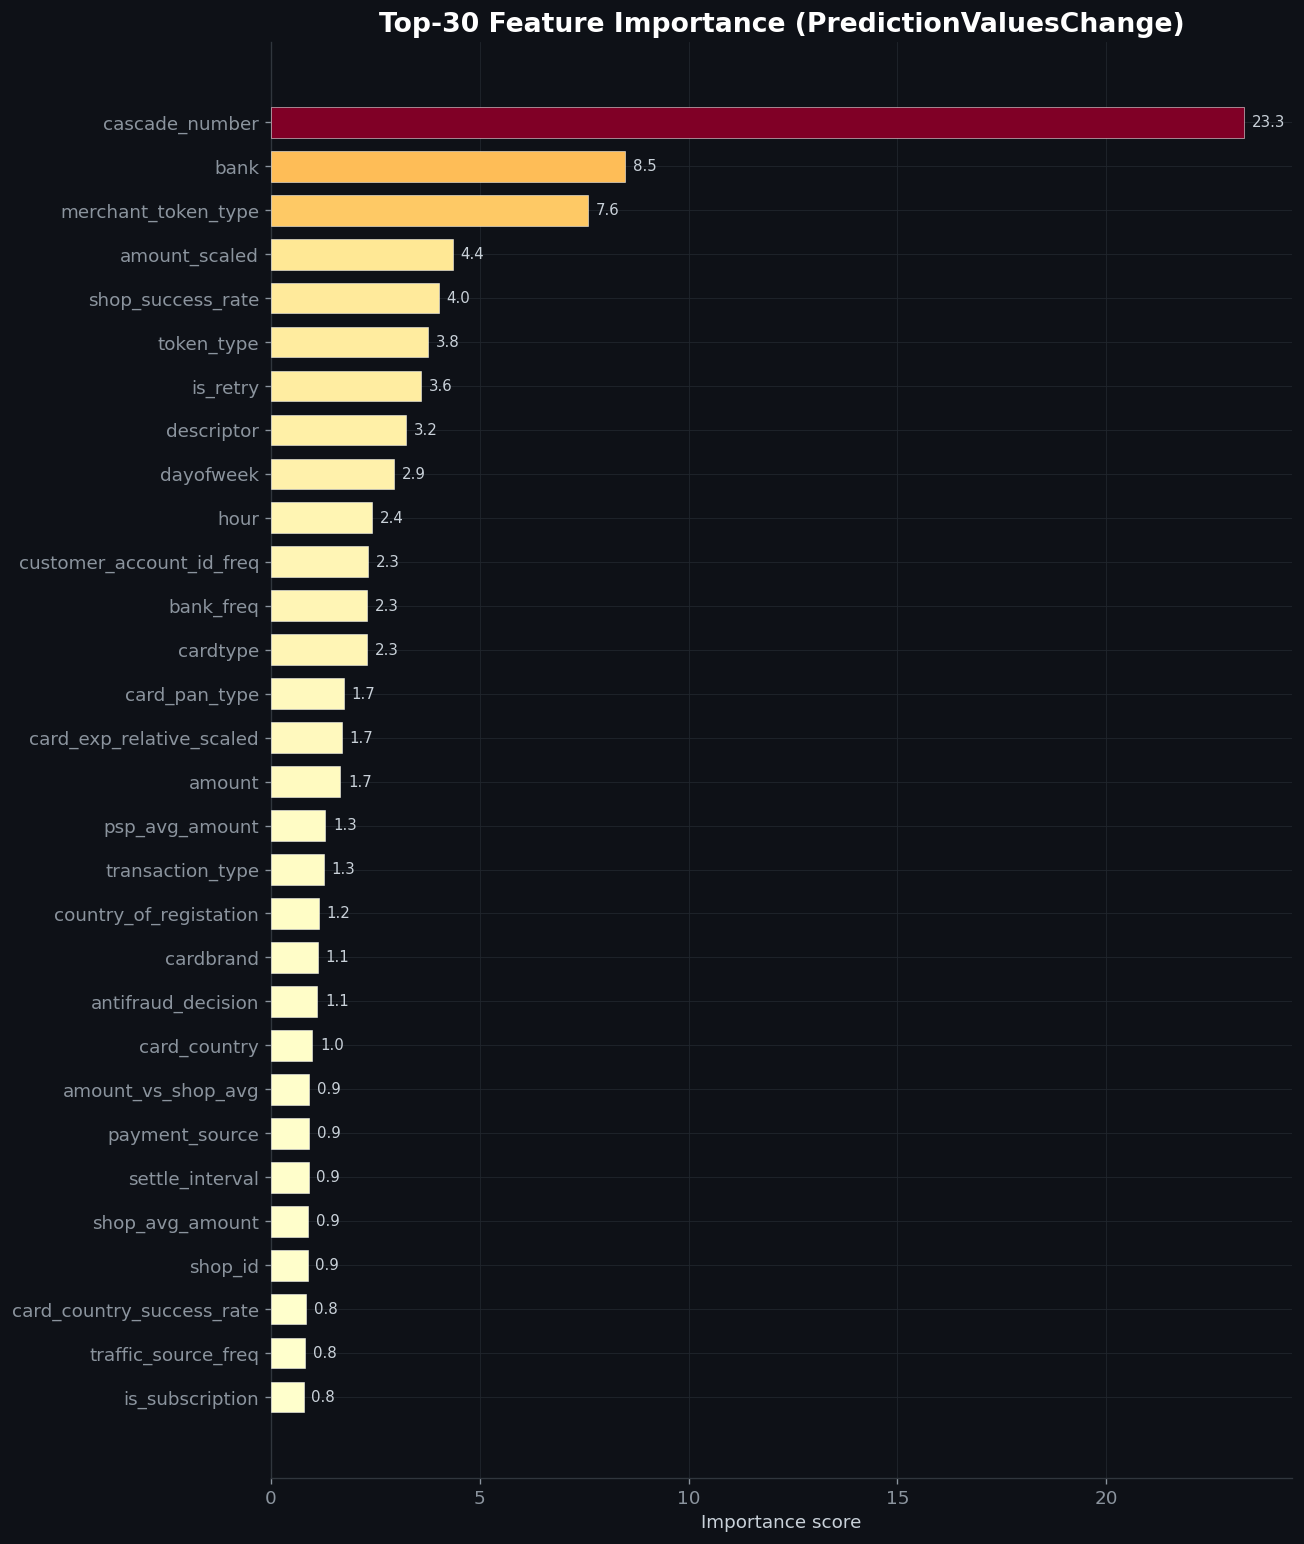

                  feature  importance
           cascade_number   23.291373
                     bank    8.483166
      merchant_token_type    7.601676
            amount_scaled    4.350098
        shop_success_rate    4.023382
               token_type    3.754922
                 is_retry    3.597277
               descriptor    3.239157
                dayofweek    2.949591
                     hour    2.418709
 customer_account_id_freq    2.317588
                bank_freq    2.313589
                 cardtype    2.294185
            card_pan_type    1.744312
 card_exp_relative_scaled    1.695550
                   amount    1.659722
           psp_avg_amount    1.305835
         transaction_type    1.263926
   country_of_registation    1.152085
                cardbrand    1.130788
       antifraud_decision    1.117557
             card_country    0.990168
       amount_vs_shop_avg    0.917356
           payment_source    0.911162
          settle_interval    0.905987
          sh

In [42]:
# --- CatBoost built-in feature importance (PredictionValuesChange) ---
importance = model.get_feature_importance(val_pool, type='PredictionValuesChange')
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importance
}).sort_values('importance', ascending=False)

top_n = min(30, len(feat_imp))
top = feat_imp.head(top_n).sort_values('importance')

fig, ax = plt.subplots(figsize=(11, 13))

norm = plt.Normalize(top['importance'].min(), top['importance'].max())
colors = [plt.cm.YlOrRd(norm(v)) for v in top['importance']]
bars = ax.barh(top['feature'], top['importance'], color=colors,
               edgecolor='white', linewidth=0.3, height=0.7, zorder=3)

for bar, v in zip(bars, top['importance']):
    ax.text(bar.get_width() + top['importance'].max() * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.1f}', va='center', fontsize=9, color='#c9d1d9')

ax.set_title(f'Top-{top_n} Feature Importance (PredictionValuesChange)',
             fontsize=16, fontweight='bold', color='white')
ax.set_xlabel('Importance score')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(feat_imp.head(30).to_string(index=False))

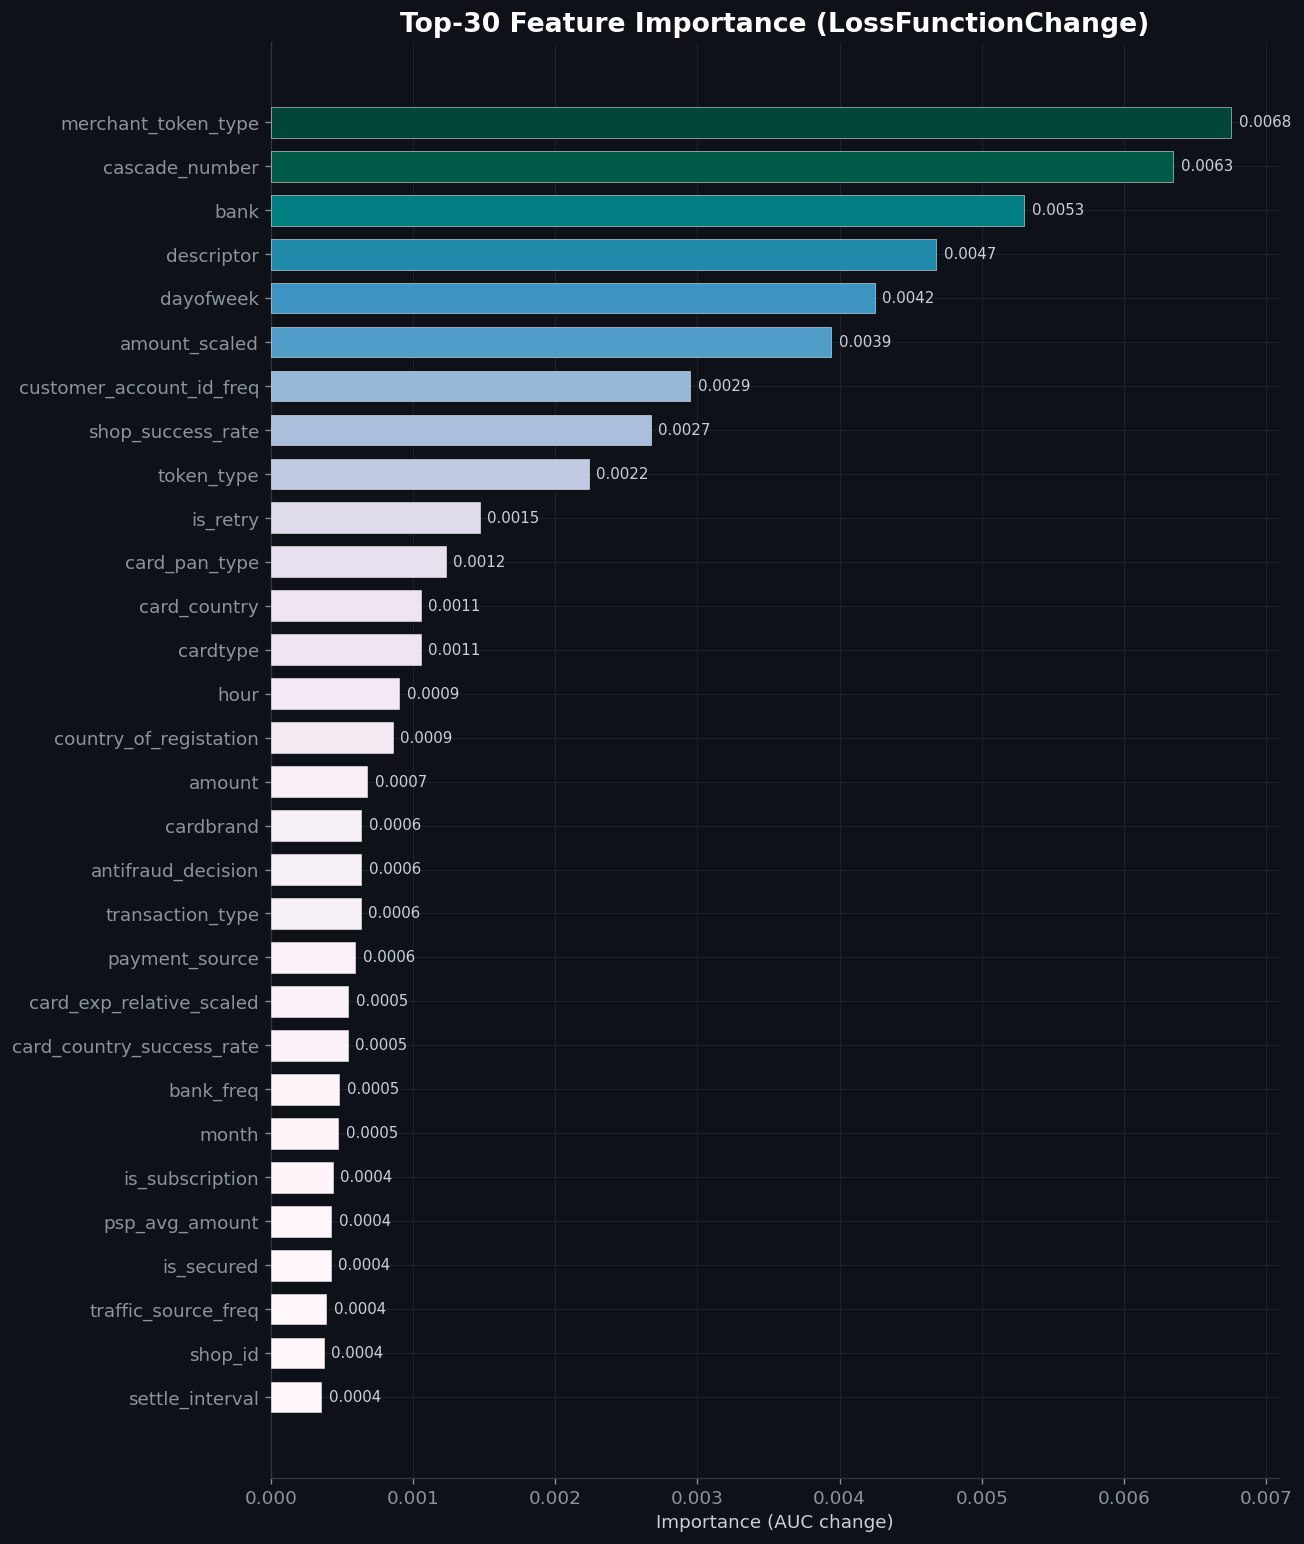

In [43]:
# --- CatBoost LossFunctionChange importance (like permutation importance) ---
lfc_importance = model.get_feature_importance(val_pool, type='LossFunctionChange')
feat_lfc = pd.DataFrame({
    'feature': feature_cols,
    'importance': lfc_importance
}).sort_values('importance', ascending=False)

top_lfc = feat_lfc.head(top_n).sort_values('importance')

fig, ax = plt.subplots(figsize=(11, 13))

norm = plt.Normalize(top_lfc['importance'].min(), top_lfc['importance'].max())
colors = [plt.cm.PuBuGn(norm(v)) for v in top_lfc['importance']]
bars = ax.barh(top_lfc['feature'], top_lfc['importance'], color=colors,
               edgecolor='white', linewidth=0.3, height=0.7, zorder=3)

for bar, v in zip(bars, top_lfc['importance']):
    ax.text(bar.get_width() + top_lfc['importance'].max() * 0.008,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.4f}', va='center', fontsize=9, color='#c9d1d9')

ax.set_title(f'Top-{top_n} Feature Importance (LossFunctionChange)',
             fontsize=16, fontweight='bold', color='white')
ax.set_xlabel('Importance (AUC change)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [44]:
!pip install shap


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
# --- SHAP analysis ---
import shap

SHAP_SAMPLE = 5000
np.random.seed(42)
sample_idx = np.random.choice(len(X_val), size=min(SHAP_SAMPLE, len(X_val)), replace=False)
X_val_sample = X_val.iloc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(Pool(X_val_sample, cat_features=cat_feature_indices))

print(f"SHAP values computed on {len(X_val_sample)} samples, shape: {shap_values.shape}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\ACER NITRO\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\ACER NITRO\AppData\Roaming\Python\Python311\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\ACER NITRO\AppData\Roaming\Python\Python311\site-packages\ipykernel\kernelapp.py", line 739, in start

AttributeError: _ARRAY_API not found

SHAP values computed on 5000 samples, shape: (5000, 62)


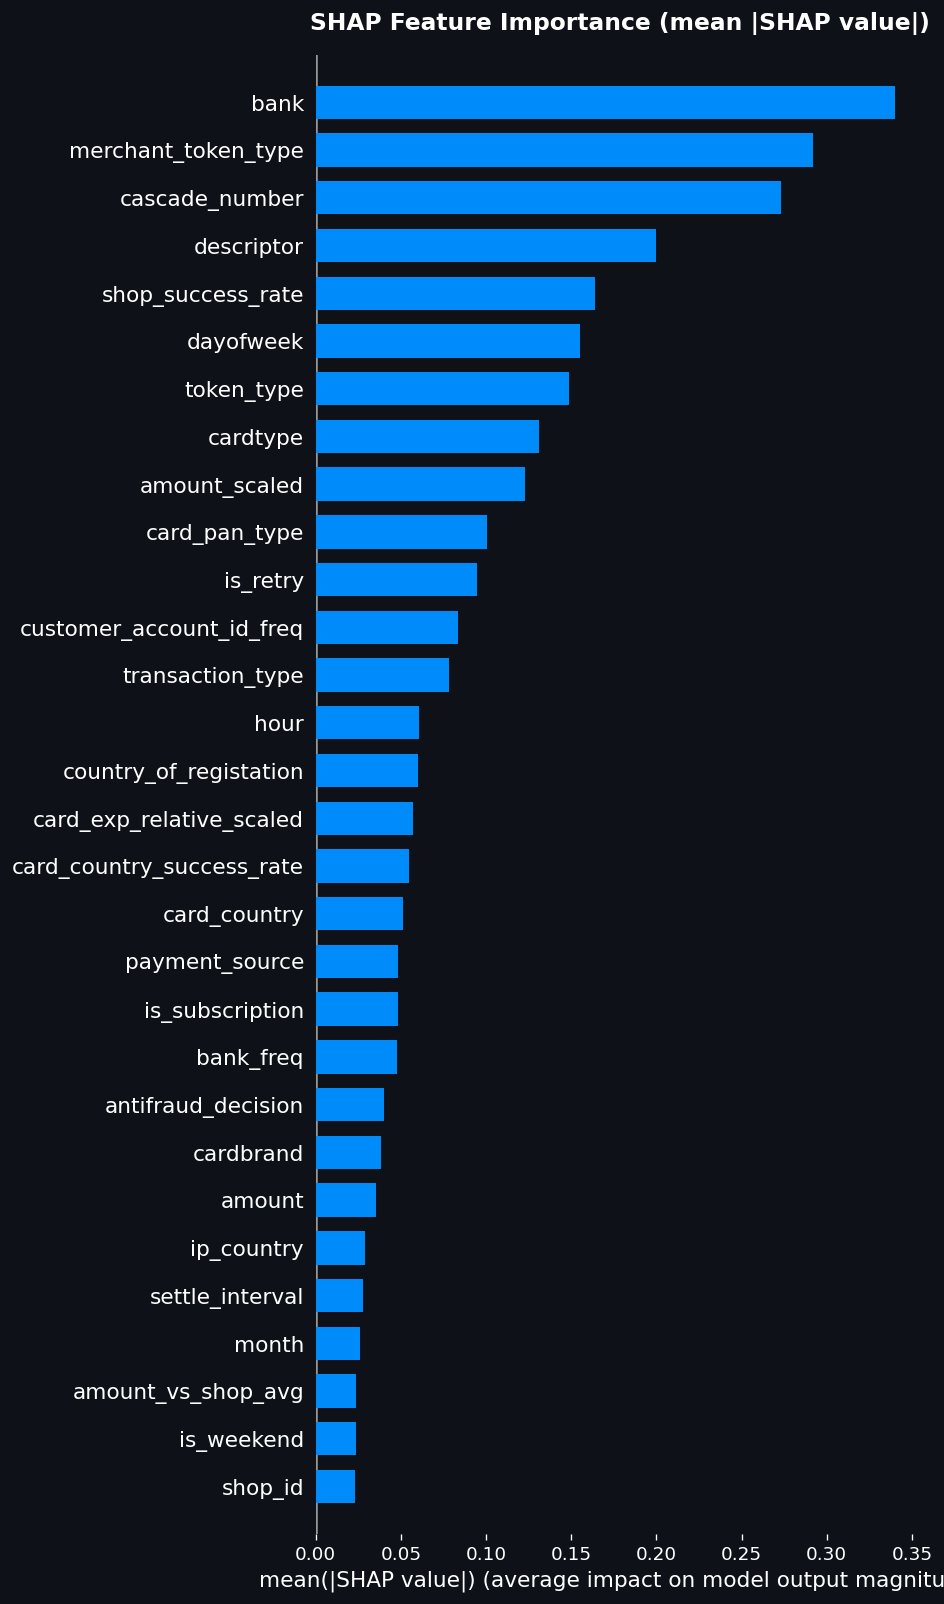

In [46]:
# --- SHAP summary plot (bar) ---
shap.summary_plot(shap_values, X_val_sample, feature_names=feature_cols,
                  plot_type='bar', max_display=30, show=False)

fig = plt.gcf()
ax = plt.gca()

fig.set_facecolor('#0e1117')
ax.set_facecolor('#0e1117')

ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')

plt.title('SHAP Feature Importance (mean |SHAP value|)', fontsize=14,
          fontweight='bold', color='white', pad=15)

plt.tight_layout()
plt.show()

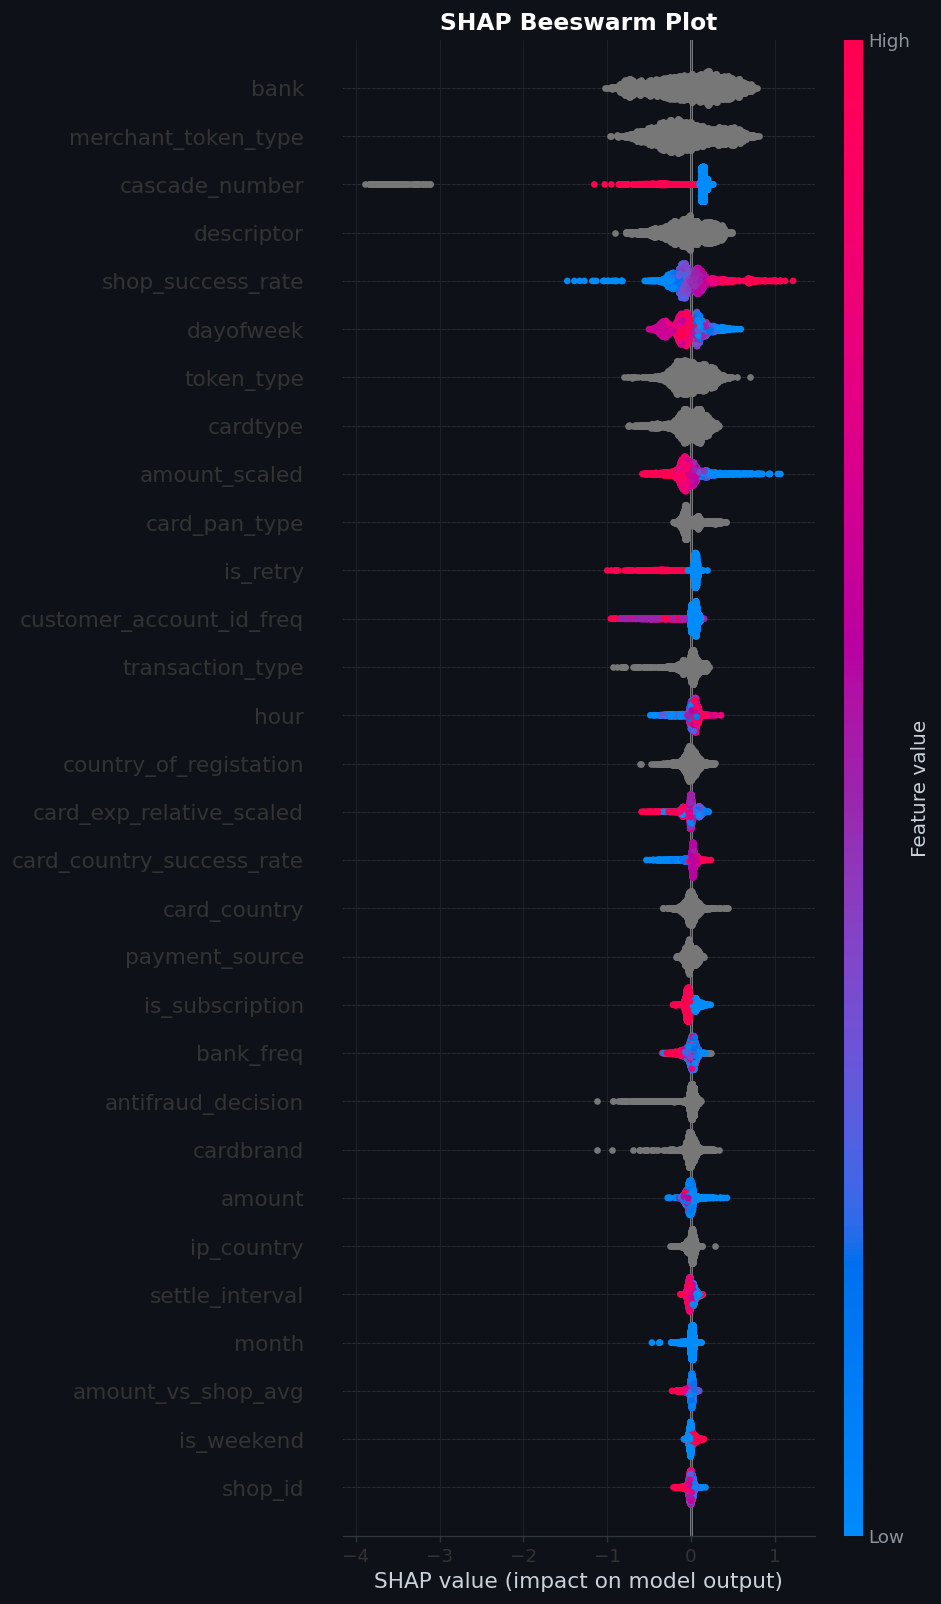

In [47]:
# --- SHAP beeswarm plot (dot) ---
shap.summary_plot(shap_values, X_val_sample, feature_names=feature_cols,
                  max_display=30, show=False)
plt.gcf().set_facecolor('#0e1117')
plt.gca().set_facecolor('#0e1117')
plt.title('SHAP Beeswarm Plot', fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

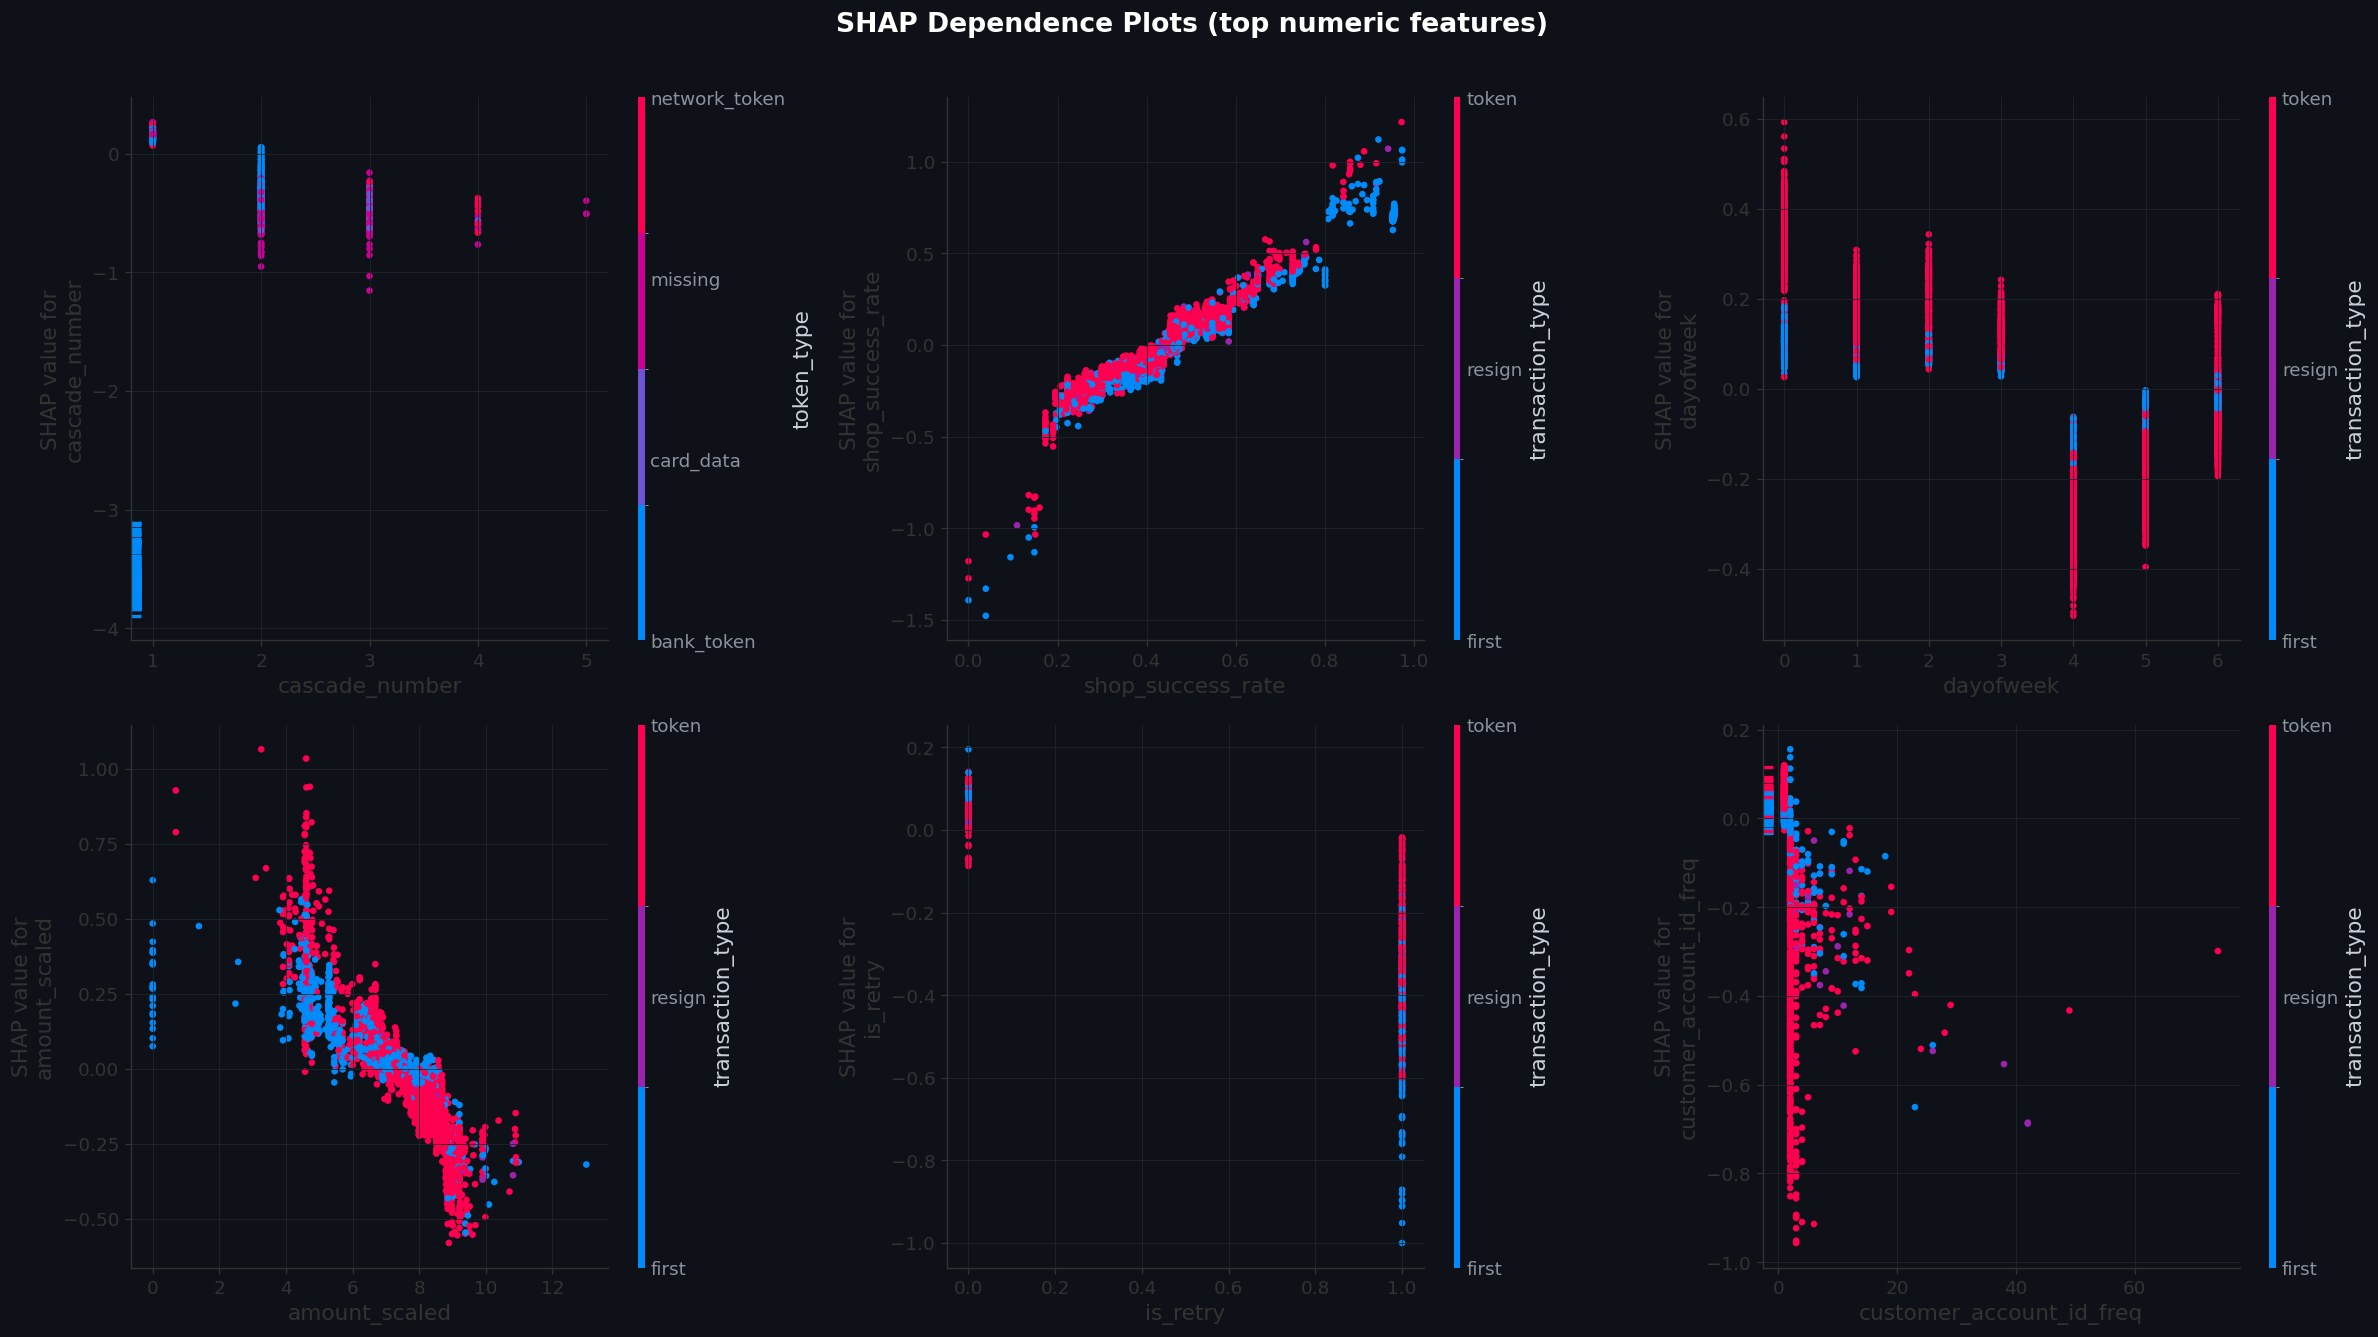

In [48]:
# --- SHAP dependence plots for top-6 numeric features ---
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_6_idx = np.argsort(mean_abs_shap)[::-1]

numeric_top = [i for i in top_6_idx if feature_cols[i] not in cat_features][:6]

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, idx in zip(axes.ravel(), numeric_top):
    shap.dependence_plot(idx, shap_values, X_val_sample,
                         feature_names=feature_cols, ax=ax, show=False)
    ax.set_facecolor('#0e1117')
fig.set_facecolor('#0e1117')
plt.suptitle('SHAP Dependence Plots (top numeric features)',
             y=1.01, fontsize=16, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

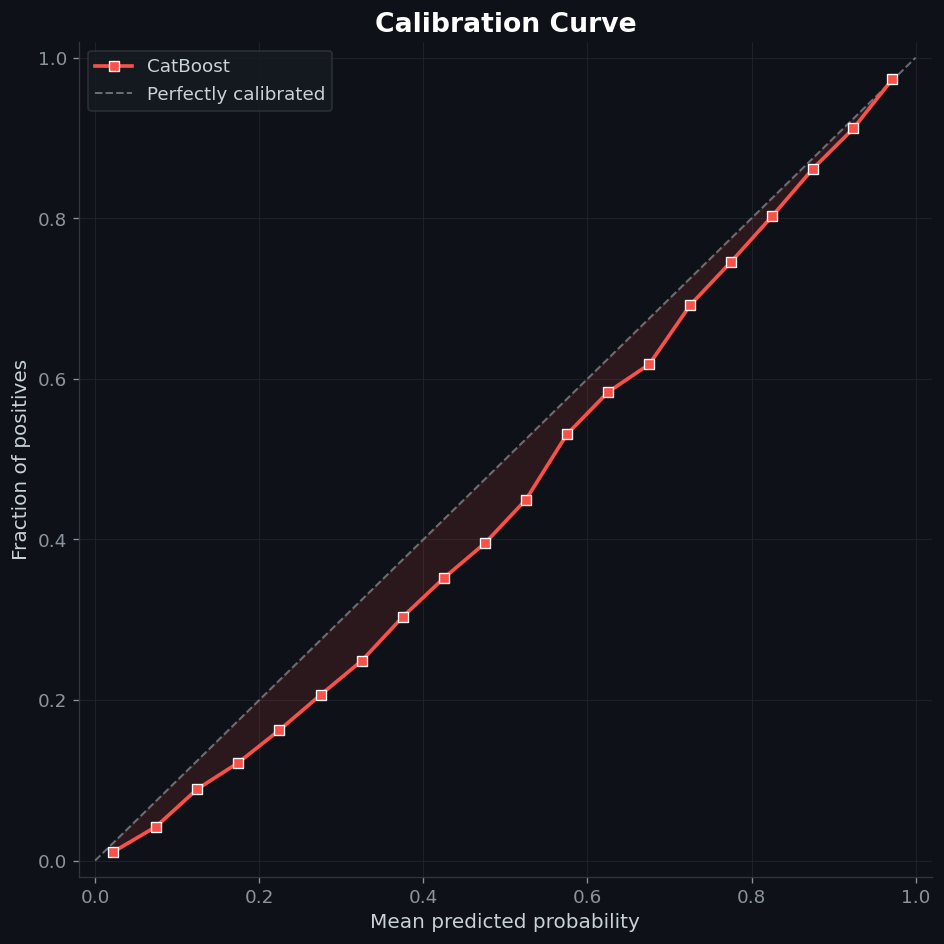

In [49]:
# --- Calibration curve ---

prob_true, prob_pred = calibration_curve(y_val, y_val_proba, n_bins=20, strategy='uniform')

fig, ax = plt.subplots(figsize=(8, 8))
ax.fill_between(prob_pred, prob_true, prob_pred, alpha=0.12, color=PAL['red'], zorder=2)
ax.plot(prob_pred, prob_true, 's-', color=PAL['red'], lw=2.2, markersize=6,
        markeredgecolor='white', markeredgewidth=0.8, label='CatBoost', zorder=3)
ax.plot([0, 1], [0, 1], '--', color=PAL['gray'], lw=1.2, alpha=0.7, label='Perfectly calibrated')
ax.set_xlabel('Mean predicted probability', fontsize=12)
ax.set_ylabel('Fraction of positives', fontsize=12)
ax.set_title('Calibration Curve', fontsize=16, fontweight='bold', color='white')
ax.legend(fontsize=11)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

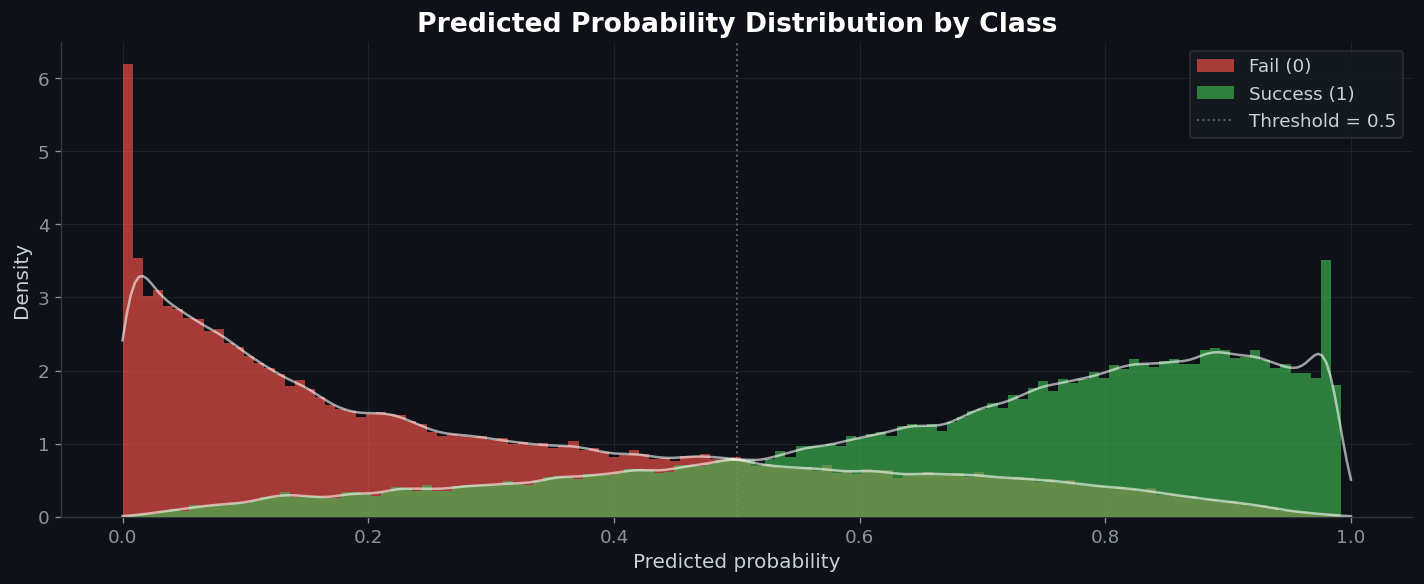

In [50]:
# --- Predicted probability distribution (val set) ---
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(y_val_proba[y_val == 0], bins=120, alpha=0.65, label='Fail (0)',
        color=PAL['red'], density=True, edgecolor='none', zorder=3)
ax.hist(y_val_proba[y_val == 1], bins=120, alpha=0.65, label='Success (1)',
        color=PAL['green'], density=True, edgecolor='none', zorder=3)

for cls, color in [(0, PAL['red']), (1, PAL['green'])]:
    vals = y_val_proba[y_val == cls]
    kde = gaussian_kde(vals, bw_method=0.05)
    xs = np.linspace(0, 1, 300)
    ax.plot(xs, kde(xs), color='white', lw=1.5, alpha=0.6, zorder=4)

ax.axvline(0.5, color=PAL['gray'], ls=':', lw=1.2, alpha=0.6, label='Threshold = 0.5')
ax.set_xlabel('Predicted probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Predicted Probability Distribution by Class', fontsize=16, fontweight='bold', color='white')
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

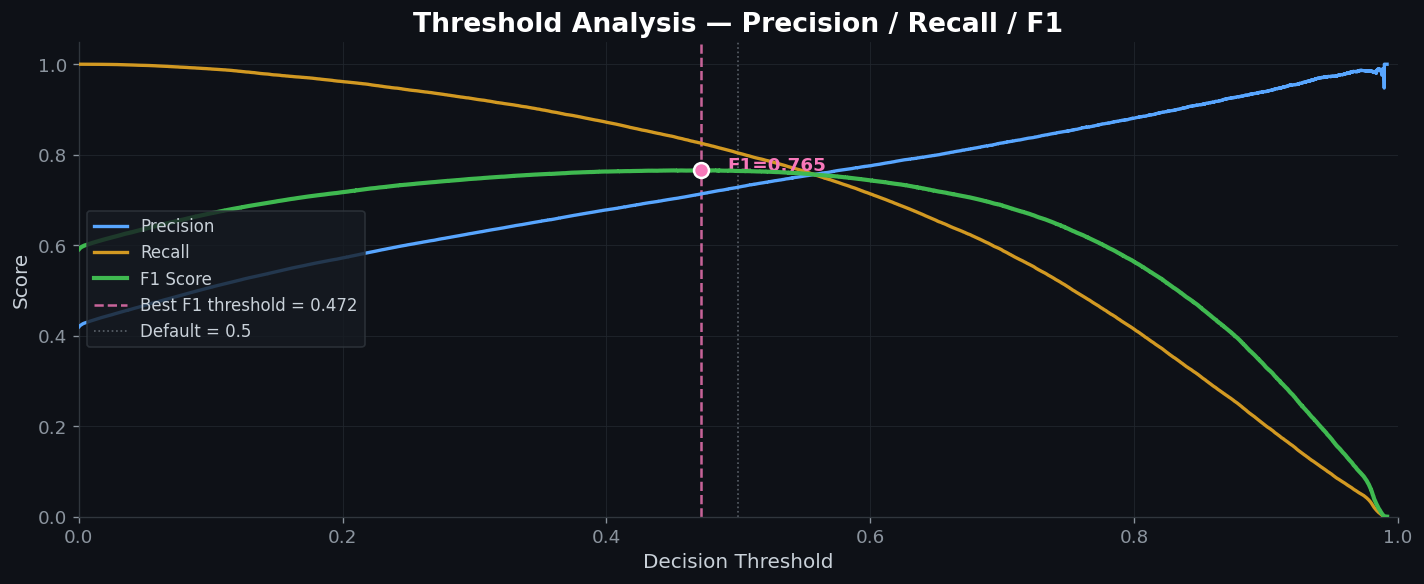

  Optimal threshold (max F1): 0.4717  ->  F1 = 0.7655


In [51]:
# --- Threshold Analysis: Precision, Recall, F1 vs Decision Threshold ---
from sklearn.metrics import f1_score as f1_fn

prec_t, rec_t, thresholds_t = precision_recall_curve(y_val, y_val_proba)
f1_t = 2 * (prec_t[:-1] * rec_t[:-1]) / (prec_t[:-1] + rec_t[:-1] + 1e-12)
best_idx = np.argmax(f1_t)
best_thresh = thresholds_t[best_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_t, prec_t[:-1], color=PAL['blue'], lw=2, label='Precision', zorder=3)
ax.plot(thresholds_t, rec_t[:-1], color=PAL['orange'], lw=2, label='Recall', zorder=3)
ax.plot(thresholds_t, f1_t, color=PAL['green'], lw=2.5, label='F1 Score', zorder=4)

ax.axvline(best_thresh, color=PAL['pink'], ls='--', lw=1.5, alpha=0.8,
           label=f'Best F1 threshold = {best_thresh:.3f}')
ax.axvline(0.5, color=PAL['gray'], ls=':', lw=1, alpha=0.6, label='Default = 0.5')

ax.scatter(best_thresh, f1_t[best_idx], color=PAL['pink'], s=80,
           edgecolor='white', linewidth=1.5, zorder=5)
ax.text(best_thresh + 0.02, f1_t[best_idx],
        f'F1={f1_t[best_idx]:.3f}', fontsize=11, color=PAL['pink'], fontweight='bold')

ax.set_xlabel('Decision Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Threshold Analysis — Precision / Recall / F1',
             fontsize=16, fontweight='bold', color='white')
ax.legend(fontsize=10, loc='center left')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
print(f"  Optimal threshold (max F1): {best_thresh:.4f}  ->  F1 = {f1_t[best_idx]:.4f}")

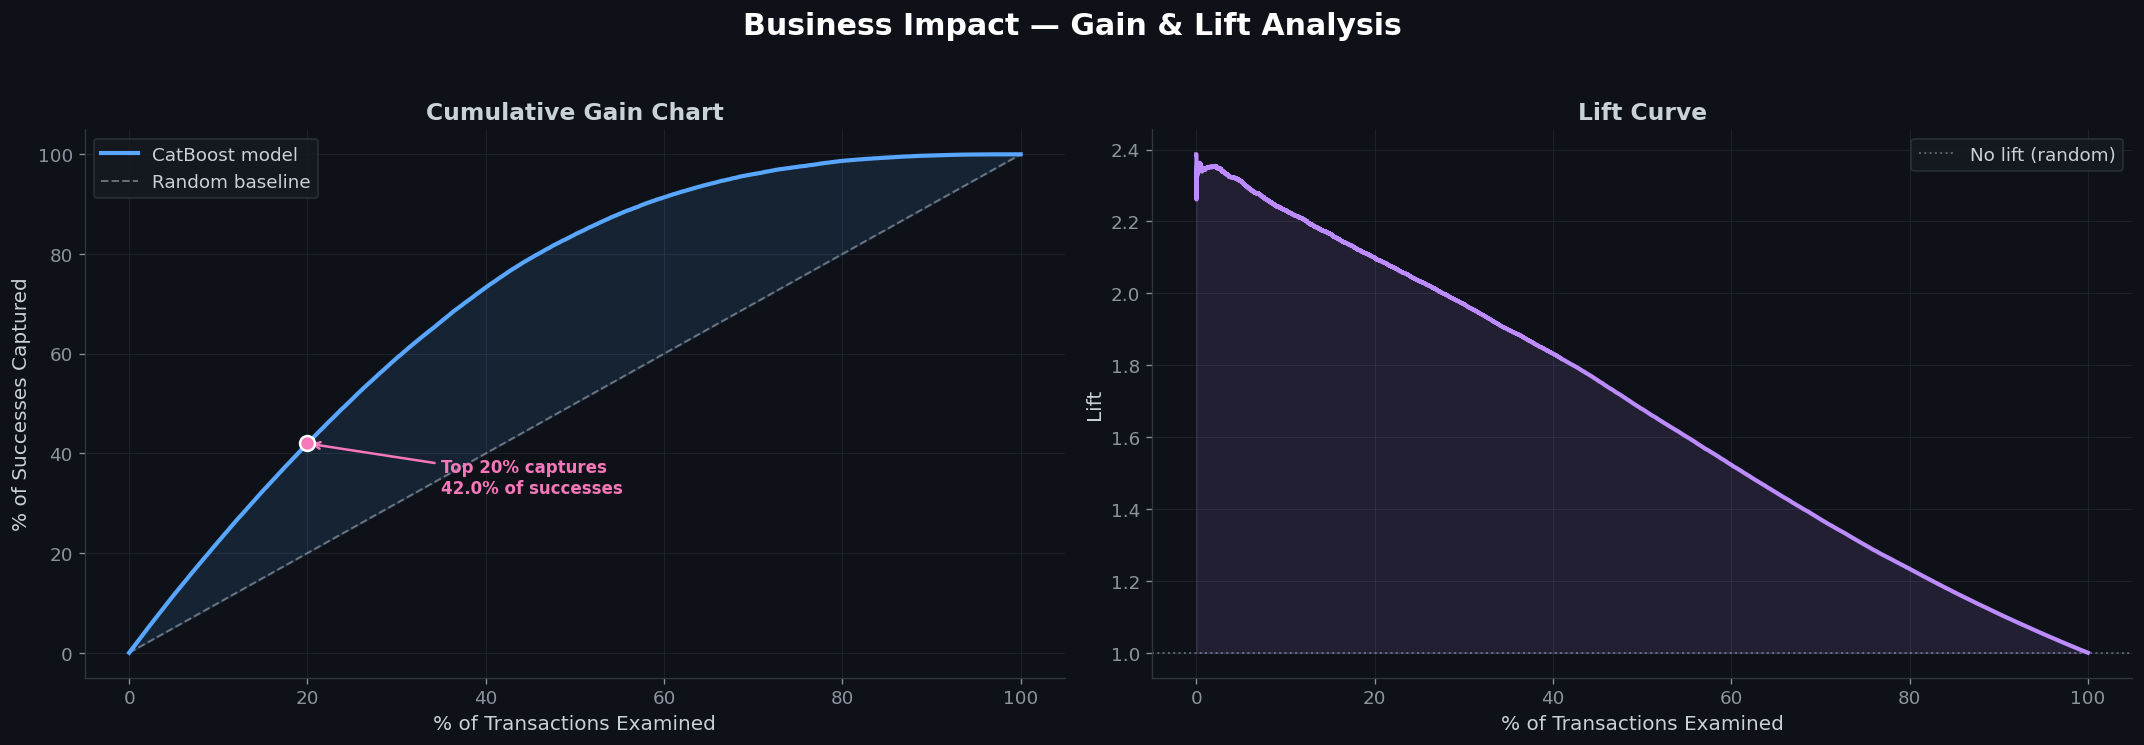

  Top 10% captures 22.3% of successes (lift = 2.23x)
  Top 20% captures 42.0% of successes (lift = 2.10x)
  Top 50% captures 83.9% of successes (lift = 1.68x)


In [52]:
# --- Cumulative Gain & Lift Curve (Business Impact) ---

order = np.argsort(-y_val_proba)
y_sorted = np.array(y_val)[order]
n = len(y_sorted)
cum_positives = np.cumsum(y_sorted)
total_positives = y_sorted.sum()

pct_sample = np.arange(1, n + 1) / n
gain = cum_positives / total_positives

baseline = pct_sample
lift = gain / baseline

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].fill_between(pct_sample * 100, gain * 100, baseline * 100, alpha=0.12,
                     color=PAL['blue'], zorder=2)
axes[0].plot(pct_sample * 100, gain * 100, color=PAL['blue'], lw=2.5, zorder=3,
             label='CatBoost model')
axes[0].plot(pct_sample * 100, baseline * 100, '--', color=PAL['gray'], lw=1.2,
             alpha=0.7, label='Random baseline')

idx_20 = int(0.2 * n)
axes[0].scatter(20, gain[idx_20] * 100, color=PAL['pink'], s=80,
                edgecolor='white', linewidth=1.5, zorder=5)
axes[0].annotate(f'Top 20% captures\n{gain[idx_20]*100:.1f}% of successes',
                 xy=(20, gain[idx_20] * 100), xytext=(35, gain[idx_20] * 100 - 10),
                 fontsize=10, color=PAL['pink'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=PAL['pink'], lw=1.5))
axes[0].set_xlabel('% of Transactions Examined', fontsize=12)
axes[0].set_ylabel('% of Successes Captured', fontsize=12)
axes[0].set_title('Cumulative Gain Chart', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(pct_sample * 100, lift, color=PAL['purple'], lw=2.5, zorder=3)
axes[1].axhline(1.0, color=PAL['gray'], ls=':', lw=1.2, alpha=0.6, label='No lift (random)')
axes[1].fill_between(pct_sample * 100, lift, 1, where=(lift > 1), alpha=0.12,
                     color=PAL['purple'], zorder=2)
axes[1].set_xlabel('% of Transactions Examined', fontsize=12)
axes[1].set_ylabel('Lift', fontsize=12)
axes[1].set_title('Lift Curve', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Business Impact — Gain & Lift Analysis',
             fontsize=18, fontweight='bold', color='white', y=1.03)
plt.tight_layout()
plt.show()
print(f"  Top 10% captures {gain[int(0.1*n)]*100:.1f}% of successes (lift = {lift[int(0.1*n)]:.2f}x)")
print(f"  Top 20% captures {gain[int(0.2*n)]*100:.1f}% of successes (lift = {lift[int(0.2*n)]:.2f}x)")
print(f"  Top 50% captures {gain[int(0.5*n)]*100:.1f}% of successes (lift = {lift[int(0.5*n)]:.2f}x)")

# Test Set Prediction

In [53]:
# --- Generate test predictions ---
test_pool = Pool(X_test, cat_features=cat_feature_indices)
test_proba = model.predict_proba(test_pool)[:, 1]
test_pred = (test_proba >= 0.452).astype(int)

submission = pd.DataFrame({
    'psp_order_id': _test_psp_order_ids,
    'is_success': test_pred
})

submission.to_csv('submission.csv', index=False)
print(f"Submission shape: {submission.shape}")
print(f"Prediction distribution:\n{submission['is_success'].value_counts()}")
submission.head(10)

Submission shape: (667317, 2)
Prediction distribution:
is_success
1    342776
0    324541
Name: count, dtype: int64


,psp_order_id,is_success
0,132567605269a21be6cfafa,0
1,1317972863699cbac599380,0
2,132294542169a08693db13d,1
3,132728622069a304949e544,1
4,132706472669a2e8bed27d5,0
5,1320696538699ee1fa2bc08,0
6,132663968169a2a52a52c21,1
7,1319141498699dab1a45e02,1
8,132707402669a2e9f91f524,1
9,132233350569a01e5267098,1
